BH — Buy & Hold (baseline)

Intent: Benchmark. “Do nothing” after initial buys.

Cash model: Per-symbol (no pooling).

Buys: On a symbol’s first day, invest a fixed amount; then just hold.

Sells: None.

Allocation signal: Ignores pos_frac/score.

Metrics to watch: Daily equal-weight BH return, cumulative BH curve. Realized% is not used (no decisions after day 1).

S2 — Sequestered accounts (one mini-portfolio per symbol)

Intent: Respect signals without cross-subsidizing symbols.

Cash model: Per-symbol cash account (no pooling).

Buys: Spend pos_frac × symbol_cash.

Sells: Fractional—sell pos_frac × shares; proceeds stay with that symbol.

Allocation signal: pos_frac only (ignores score by default).

Notes: Great sandbox to understand raw signal behavior per name.

S3 — Pooling baseline (fractional sells; pooled cash)

Intent: One pot of cash; gentle rebalancing via fractional sells.

Cash model: Pooled across symbols.

Buys: Allocate pool ∝ pos_frac across BUYs.

Sells: Fractional (reduce position by pos_frac); proceeds to the pool.

Allocation signal: pos_frac only (no confidence weighting).

S4 — Flatten-on-SELL (pooled cash)

Intent: S3 behavior but faster de-risking on SELL.

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac.

Sells: Flatten (exit 100%) on SELL.

Allocation signal: pos_frac only.

S5 — Weighted & flatten (pooled cash + confidence weighting)

Intent: Favor higher-confidence names when buying; still flatten on SELL.

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score).

Sells: Flatten on SELL.

Allocation signal: pos_frac and score (mapped to ~0.5–1.5× weight).

Notes: If score is missing, falls back to equal weight within BUYs.

S6 — Budgeted, evidence-weighted (fractional sells; pooled cash)

Intent: Use signal size and evidence strength; don’t always flatten.

Cash model: Pooled.

Buys: Allocate ∝ pos_frac × evidence_weight, then clamp per-row fraction (e.g., [0.00–0.50]) before normalizing.

Sells: Fractional (respect pos_frac).

Allocation signal: pos_frac, score→weight, and sample-size ramp toward full weight as n_seen grows.

Notes: More conservative via budget clamps; smoother turnover.

S7 — Budgeted, evidence-weighted with flatten (pooled cash)

Intent: S6 buy logic + decisive exits.

Cash model: Pooled.

Buys: Same as S6 (evidence-weighted with clamps).

Sells: Flatten on SELL.

Allocation signal: pos_frac, score, sample-size ramp, clamps.

S8 — “Only Winners” gate (pooled, flatten sells, eligibility filter)

Intent: Trade only symbols that have proven themselves so far.

Eligibility: A symbol is tradable today only if its prior-day cumulative realized TWR ≥ 0 (use a tiny epsilon for float noise).

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score) but mask to 0 if ineligible.

Sells: Flatten on SELL.

Allocation signal: pos_frac, score (0.5–1.5×), eligibility mask.

Variants: Optional Bayesian accuracy multiplier before clamping.

S9 — “Only Recent Winners” (new; like S8 but rolling 10)

Intent: Trade names with recent proof, not lifetime.

Eligibility: Tradable today only if the rolling last-10 inferences realized TWR > 0 (computed per symbol, shifted so it uses only prior info).

Cash model: Pooled.

Buys: Allocate pool ∝ pos_frac × dyn_weight(score) masked by S9 eligibility.

Sells: Flatten on SELL.

Allocation signal: pos_frac, score (0.5–1.5×), rolling-10 eligibility mask.

Why it exists: Catches momentum/regime shifts faster than S8’s all-history gate.

1. What S10, S11, S12, and S13 are doing
S10 – CAGR-weighted “good symbols only”

Source data:

Uses the stable_infer history (same as other strategies).

Uses splityear_summary.csv to get a per-symbol RL out-of-sample CAGR (rl_oos_cagr).

Logic:

Load splityear_summary.csv, keep only rows with positive rl_oos_cagr.

Clip rl_oos_cagr at the 95th percentile to avoid a single monster symbol dominating.

Build a weight dictionary S10_train_WEIGHTS: {symbol -> clipped_cagr}.

On any day where a symbol has a BUY pos_frac from the RL model:

If the symbol is not in S10_train_WEIGHTS → it’s effectively gated out (weight 0).

If it is in S10_train_WEIGHTS → its position size is pos_frac * normalized_cagr.

Portfolio is then scaled so the daily weights sum to the target equity fraction.

So S10’s “gating” is purely: “did this symbol have positive rl_oos_cagr in the splityear summary?”

S11 – Rolling wins/losses gating, “K-of-N good”

Source data:

Uses the same event frame ev built from stable_infer (per symbol, per day).

Computes ret_1d / ret_fwd and a correct/wrong flag based on whether the RL action direction matched the next-day move.

Key constants (from the notebook):

S11_ACTIVATION_GOOD – how many good (correct) trades you need in the recent window.

S11_DEACTIVATION_BAD – how many bad trades you’re allowed before getting gated out.

S11_LOOKBACK – length of the rolling window (number of past trades to consider).

S11_AGE_CAP, S11_AGE_DIV – control how “seniority” (age) boosts weight once active.

Logic:

For each symbol, walk forward through time in date order.

Maintain rolling counts of “good” and “bad” results across the last S11_LOOKBACK trades.

On each day you compute:

elig_s11 – True if:

the symbol has enough good results (>= S11_ACTIVATION_GOOD), and

not too many bad results (< S11_DEACTIVATION_BAD).

active_age_s11 – an “age” for how long the symbol has been in an eligible/active state.

When building S11’s weights:

If elig_s11 is False → the symbol is gated out for S11 that day.

If elig_s11 is True, its base weight is pos_frac,
and then it gets a multiplier based on active_age_s11
(up to the S11_AGE_CAP).

So S11 is: “only trade symbols whose recent history of RL calls has been good enough, and give older, proven symbols a bit more weight.”

S12 – Streak-based activation with “bad while active” deactivation

This is the more “stateful” gating tracked in the s12_state table.

Key constants:

S12_ACTIVATION_GOOD – number of correct calls in a row required to activate a symbol.

S12_DEACTIVATION_BAD – number of wrong calls while active required to deactivate.

S12_AGE_CAP, S12_AGE_DIV – similar age/weight logic as S11.

State tracked per (symbol, date) in build_s12_state_table:

active – whether the symbol is currently active for S12.

age – how many days it has been active.

good_streak – consecutive correct calls leading up to/while active.

bad_streak – consecutive incorrect calls.

bad_while_active – how many wrong calls have happened since activation.

flags – human-readable notes like "ACTIVATE", "DEACTIVATE", "STILL_ACTIVE", "HOLD_OR_WRONG".

Logic:

Walk each symbol’s history in time order.

If not active:

Increase good_streak on correct trades, reset on wrong/HOLD.

Once good_streak >= S12_ACTIVATION_GOOD, set active=True, age=0, bad_while_active=0 and set flag "ACTIVATE".

If active:

Increment age each trading day.

On each trade:

If correct → reset bad_streak, bad_while_active unchanged, flag "STILL_ACTIVE".

If wrong:

Increment bad_streak and bad_while_active.

If bad_while_active >= S12_DEACTIVATION_BAD → set active=False, reset streaks, flag "DEACTIVATE".

When S12 weights are built:

Use only rows where active is True and the RL action is a BUY.

Weight = pos_frac * age-based multiplier (capped by S12_AGE_CAP).

So S12 is: “don’t start trading a symbol until it proves itself with a streak of good calls, and stop trading once it’s had too many mistakes while active.”

S13 – S12-gated, age-boosted portfolio

S13 sits on top of S12’s state.

Logic:

Start from the same base RL events as S10/S11.

For each symbol/day:

Require s12_state.active == True – that is, S12 has activated the symbol and not yet deactivated it.

Only consider BUY actions (no HOLD/SELL).

Use pos_frac as the base position size.

Apply an age modifier based on the S12 age:

e.g. weight ∝ pos_frac * f(age) with an age cap/div similar to S12/S11.

Thus:

S13 only holds symbols that have “graduated” through S12’s stricter streak-based gating.

Older active positions (higher S12 age) get relatively more weight.

So S13 is: “take S2-style positions, but only for symbols that are in good standing under S12’s streak rules, and favor those that have stayed good for a long time.”

In [48]:
# EDIT THIS: symbols you want to include in the "select" slice
SELECT_SYMBOLS = ["NVDA",'QS','SLDP','GOOGL','MSFT',
 #'BYND',
 
 "AAPL", 'AEP', 'AI', 'ALB', 'AMD', 'AMSC', 'ARQQ', 'ARRY', 'BHP',  'CHGG', 'CLNE', 'COST', 'ELVA', 
 'ENPH', 'ENVX', 'EOSE', 'EVGO', 'FLNC', 'FSLR' 
 ,'GEVO', 'GOOGL', 'IBM', 'INFA', 'INTC', 'IONQ', 'ITRI', 
 'LCID', 'MDB', 'MNTK', 'MRK', 'MSFT', 'MU', 'MVST', 'NFLX', 
 'NVDA', 'NVTS', 'NXT', 'PAYO', 'PG', 'PGR', 'PLUG', 'POWI', 'PSTG', 'QBTS', 'QS', 'QUBT', 'RGTI', 
 'RMBS', 'RNW', 'ROP', 'SEDG', 'SLDP', 'SMCI', 'SNOW', 'TDC', 'TM', 'TRV', 'TSM', 'VICR', 'VZ', 'XEL'
]

In [49]:
# --- Patched Cell A: discover & classify (skip aggregates) ---
from pathlib import Path
import re
import pandas as pd

LOGS_DIR = Path(".")  # notebook is in ./logs

SKIP_RE = re.compile(r"(^_|combined|history|normalized)", re.IGNORECASE)
csvs = sorted(p for p in LOGS_DIR.glob("*.csv") if not SKIP_RE.search(p.name))

def read_header(path: Path):
    try:
        return pd.read_csv(path, nrows=0, sep=None, engine="python", encoding="utf-8-sig").columns.str.lower().tolist()
    except Exception:
        return []

def classify(cols):
    c = set(cols)
    # Explicitly mark known aggregate outputs if they sneak through
    if {"source_file","schema_version","src_kind"} <= c:
        return "aggregate_output"

    # Sept live snapshot (your example)
    if {"timestamp_utc","symbol","price_3pm","signal","pos_frac","qty","bias","buf_scale","mid","upper","lower"} <= c:
        return "sept_live_snapshot"

    # Stabilized infer (Oct+)
    if "symbol" in c and (("sig" in c) or ("signal" in c) or ("side" in c)) and {"mid","upper","lower"} <= c:
        return "stable_infer"

    # Generic banded logs
    if {"symbol","mid","upper","lower"} <= c:
        return "generic_banded"

    return "unknown"

catalog = []
for p in csvs:
    cols = read_header(p)
    kind = classify(cols)
    if kind not in {"unknown", "aggregate_output"}:
        catalog.append((p, kind, cols))

print(f"Found {len(catalog)} usable CSVs in {LOGS_DIR.resolve()}")
for p, kind, cols in catalog[:10]:
    print(f"  - {p.name:30s}  [{kind}]  cols={len(cols)}")


Found 71 usable CSVs in C:\Users\brobi\OneDrive\Desktop\Algo1\logs
  - infer_2025-09-15.csv            [sept_live_snapshot]  cols=12
  - infer_2025-09-16.csv            [sept_live_snapshot]  cols=12
  - infer_2025-09-18.csv            [sept_live_snapshot]  cols=12
  - infer_2025-09-19.csv            [sept_live_snapshot]  cols=12
  - infer_2025-09-22.csv            [stable_infer]  cols=14
  - infer_2025-09-23.csv            [stable_infer]  cols=14
  - infer_2025-09-24.csv            [stable_infer]  cols=14
  - infer_2025-09-25.csv            [stable_infer]  cols=14
  - infer_2025-09-26.csv            [stable_infer]  cols=14
  - infer_2025-09-29.csv            [stable_infer]  cols=14


In [50]:
# --- Patch: show date range across infer files ---
import pandas as pd
import re

def _pick_time_col(cols):
    # prefer explicit names; then fall back to any col containing 'time' or 'date'
    pref = ["timestamp_utc", "timestamp_et", "timestamp", "as_of", "date"]
    cset = set(cols)
    for k in pref:
        if k in cset:
            return k
    cands = [c for c in cols if re.search(r"(time|date)", c)]
    return cands[0] if cands else None

overall_min = None
overall_max = None
files_used  = 0

for p, kind, cols in catalog:
    tcol = _pick_time_col(cols)
    if not tcol:
        continue
    try:
        # read only the time column (case-insensitive)
        s = pd.read_csv(
            p,
            usecols=lambda c: c.strip().lower() == tcol,
            encoding="utf-8-sig"
        )
        # normalize column name to lower so we can reference tcol directly
        s.columns = s.columns.str.strip().str.lower()
        dt = pd.to_datetime(s[tcol], errors="coerce")
        if dt.notna().any():
            fmin, fmax = dt.min(), dt.max()
            overall_min = fmin if overall_min is None else min(overall_min, fmin)
            overall_max = fmax if overall_max is None else max(overall_max, fmax)
            files_used += 1
    except Exception:
        pass  # skip unreadable files silently; they're already filtered by catalog

if overall_min is not None:
    print(f"Date range across {files_used}/{len(catalog)} infer files: {overall_min} → {overall_max}")
else:
    print("Date range: unavailable (no recognizable time/date column found).")


Date range across 71/71 infer files: 2025-09-16 01:16:53+00:00 → 2025-12-27 22:35:55+00:00


In [51]:
# --- Cell B: loader & normalizer for all recognized variants (UPDATED) ---
from pathlib import Path
import numpy as np
import re
import pandas as pd

BASE_COLS = [
    "timestamp_utc","symbol","date","price","bias",
    "buf_scale","pos_frac","pre_sig","sig","side",
    "mid","upper","lower","buf"
]

# Map many historical names → unified schema
RENAME_MAP = {
    # date/time
    "date_bar":"date","bar_date":"date","date_iso":"date","day":"date",
    "timestamp":"timestamp_utc","time_utc":"timestamp_utc","ts_utc":"timestamp_utc","ts":"timestamp_utc",
    # price fields
    "close":"price","last":"price","last_price":"price",
    "price_3pm":"price","price_cutoff":"price","price_live":"price",
    # bands
    "m":"mid","u":"upper","l":"lower",
    # policy / signals
    "policy":"bias","regime":"bias",
    "pre_signal":"pre_sig","presig":"pre_sig",
    "signal":"sig","signal_final":"sig",
    "action":"side","sig_text":"side",
}

def _normalize_colnames(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    overlap = set(RENAME_MAP) & set(df.columns)
    if overlap:
        df = df.rename(columns={k: RENAME_MAP[k] for k in overlap})
    return df

def _map_side_to_text(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    # common string variants
    if s in {"BUY", "B", "LONG", "+1", "1"}:
        return "BUY"
    if s in {"SELL", "S", "SHORT", "0"}:
        return "SELL"
    if s in {"HOLD", "H", "NEUTRAL", "FLAT", "-1"}:
        return "HOLD"
    # last-ditch numeric parse
    try:
        i = int(float(s))
        return {1: "BUY", 0: "SELL", -1: "HOLD"}.get(i, np.nan)
    except Exception:
        return np.nan

def _infer_date_from_filename(name: str):
    m1 = re.search(r"(\d{4}-\d{2}-\d{2})", name)   # 2025-09-19
    m2 = re.search(r"(\d{8})", name)               # 20250919
    if m1: return pd.to_datetime(m1.group(1)).date()
    if m2: return pd.to_datetime(m2.group(1), format="%Y%m%d").date()
    return None

def read_csv_lenient(path):
    return pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")

def standardize_file(path: Path, src_kind: str) -> pd.DataFrame:
    df = read_csv_lenient(path)
    if df.empty:
        return df

    df = _normalize_colnames(df)
    df["source_file"]   = path.name
    df["src_kind"]      = src_kind
    df["log_file_date"] = _infer_date_from_filename(path.name)

    # Canonicalize symbol
    if "symbol" in df.columns:
        df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()

    # If we have timestamp in ET but no UTC, convert → UTC
    if "timestamp_utc" not in df.columns and "timestamp_et" in df.columns:
        ts_et = pd.to_datetime(df["timestamp_et"], errors="coerce")
        try:
            dt_et = ts_et.dt.tz_localize("America/New_York", nonexistent="shift_forward", ambiguous="NaT")
        except TypeError:
            dt_et = ts_et.dt.tz_localize("US/Eastern", nonexistent="shift_forward", ambiguous="NaT")
        df["timestamp_utc"] = dt_et.dt.tz_convert("UTC")

    # Ensure timestamp_utc is datetime with UTC
    if "timestamp_utc" in df.columns:
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce", utc=True)

    # --- Derive/normalize date (fills partial nulls too) ---
    ts_utc = df["timestamp_utc"] if "timestamp_utc" in df.columns else None
    if "date" not in df.columns:
        if ts_utc is not None:
            df["date"] = pd.to_datetime(ts_utc, errors="coerce").dt.date
        else:
            df["date"] = df["log_file_date"]
    else:
        d0 = pd.to_datetime(df["date"], errors="coerce").dt.date
        if ts_utc is not None:
            d1 = pd.to_datetime(ts_utc, errors="coerce").dt.date
            df["date"] = np.where(pd.isna(d0), d1, d0)
        else:
            df["date"] = np.where(pd.isna(d0), df["log_file_date"], d0)

    # --- Side normalization (handles side/sig/signal as text or numbers) ---
    if "side" in df.columns:
        df["side"] = df["side"].apply(_map_side_to_text)
    elif "sig" in df.columns:
        if df["sig"].dtype == object:
            df["side"] = df["sig"].apply(_map_side_to_text)
        else:
            df["side"] = df["sig"].map({1:"BUY", 0:"SELL", -1:"HOLD"})
    elif "signal" in df.columns:
        df["side"] = df["signal"].apply(_map_side_to_text)

    # Compute band width if missing
    if "buf" not in df.columns and {"mid","upper"}.issubset(df.columns):
        with np.errstate(invalid="ignore", divide="ignore"):
            df["buf"] = (df["upper"] - df["mid"]) / df["mid"]

    # Coerce numerics if present
    for c in ["price","buf_scale","pos_frac","mid","upper","lower","buf","pre_sig","sig","qty"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Clean impossible/inf buffer values
    if "buf" in df.columns:
        bad = ~np.isfinite(df["buf"]) | (df["buf"] <= -0.99)
        df.loc[bad, "buf"] = np.nan

    # Normalize date dtype
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

    # Add missing base cols so schema is stable
    for c in BASE_COLS:
        if c not in df.columns:
            df[c] = np.nan

    # Simple schema tag by time window
    df["schema_version"] = np.where(
        df["date"].notna() & (pd.to_datetime(df["date"]) < pd.to_datetime("2025-10-01")),
        "early_sept",
        "stable_oct_plus"
    )

    # Column order: base first, then the rest (to retain useful extras like 'qty')
    ordered = [c for c in BASE_COLS if c in df.columns] + \
              [c for c in df.columns if c not in BASE_COLS]
    return df[ordered]

# --- Cell B (tail): build all_inf from the catalog ---
dfs, failures = [], 0

# Ignore any aggregate outputs and guard against dup entries
seen = set()
filtered_catalog = []
for p, kind, cols in catalog:
    key = (p.resolve(), kind)
    if kind != "aggregate_output" and key not in seen:
        filtered_catalog.append((p, kind, cols))
        seen.add(key)

for p, kind, _cols in filtered_catalog:
    try:
        d = standardize_file(p, kind)
        if d is not None and not d.empty:
            dfs.append(d)
    except Exception as e:
        failures += 1
        print(f"⚠️ Failed to parse {p.name}: {e}")

if dfs:
    all_inf = pd.concat(dfs, ignore_index=True)
else:
    all_inf = pd.DataFrame(columns=BASE_COLS + ["source_file","src_kind","log_file_date","schema_version"])

# Hygiene: drop impossible rows, sort, and de-dup
sort_cols = [c for c in ["symbol","date","timestamp_utc"] if c in all_inf.columns]
sort_cols = [c for c in ["symbol","date","timestamp_utc"] if c in all_inf.columns]
dedup_cols = ["symbol", "date"]
if "model_kind" in all_inf.columns:
    dedup_cols.append("model_kind")

all_inf = (
    all_inf
    .dropna(subset=["symbol","date"], how="any")
    .sort_values(sort_cols, na_position="last")
    .drop_duplicates(subset=dedup_cols, keep="last")
)


print(f"Unified rows: {len(all_inf):,} | files parsed: {len(dfs)} | failures: {failures}")
print("Source kinds:\n", all_inf["src_kind"].value_counts(dropna=False))
display(all_inf.head(20))


⚠️ Failed to parse infer_2025-11-17.csv: unsupported operand type(s) for -: 'str' and 'str'
⚠️ Failed to parse infer_2025-12-05.csv: Expected 17 fields in line 1767, saw 18
Unified rows: 7,814 | files parsed: 69 | failures: 2
Source kinds:
 src_kind
stable_infer          7758
sept_live_snapshot      56
Name: count, dtype: int64


,timestamp_utc,symbol,date,price,bias,buf_scale,pos_frac,pre_sig,sig,side,...,qty,source_file,src_kind,log_file_date,schema_version,profile,exp_id,model_source,model_path,model_kind
567,2025-10-21 02:56:29+00:00,AAPL,2025-10-20,262.245,revert,0.8,0.3,0.0,0.0,SELL,...,NaN,infer_2025-10-20.csv,stable_infer,2025-10-20,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
629,2025-10-22 00:10:22+00:00,AAPL,2025-10-21,262.730,revert,1.2,0.2,0.0,0.0,SELL,...,NaN,infer_2025-10-21.csv,stable_infer,2025-10-21,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
691,2025-10-22 18:47:49+00:00,AAPL,2025-10-22,256.860,revert,1.2,0.2,0.0,0.0,SELL,...,NaN,infer_2025-10-22.csv,stable_infer,2025-10-22,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
753,2025-10-23 18:21:28+00:00,AAPL,2025-10-23,259.990,trend,1.2,0.4,1.0,1.0,BUY,...,NaN,infer_2025-10-23.csv,stable_infer,2025-10-23,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
815,2025-10-25 20:30:56+00:00,AAPL,2025-10-24,262.780,revert,1.0,0.2,0.0,0.0,SELL,...,NaN,infer_2025-10-24.csv,stable_infer,2025-10-24,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
877,2025-10-27 18:00:13+00:00,AAPL,2025-10-27,265.865,revert,1.2,0.2,0.0,0.0,SELL,...,NaN,infer_2025-10-27.csv,stable_infer,2025-10-27,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
939,2025-10-28 18:36:41+00:00,AAPL,2025-10-28,268.970,revert,1.2,0.3,0.0,0.0,SELL,...,NaN,infer_2025-10-28.csv,stable_infer,2025-10-28,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
1001,2025-10-29 19:27:40+00:00,AAPL,2025-10-29,268.710,trend,1.0,0.2,1.0,1.0,BUY,...,NaN,infer_2025-10-29.csv,stable_infer,2025-10-29,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
1063,2025-10-30 19:41:40+00:00,AAPL,2025-10-30,271.240,revert,1.0,0.4,0.0,0.0,SELL,...,NaN,infer_2025-10-30.csv,stable_infer,2025-10-30,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN
1125,2025-10-31 17:40:13+00:00,AAPL,2025-10-31,270.700,revert,1.0,0.4,0.0,0.0,SELL,...,NaN,infer_2025-10-31.csv,stable_infer,2025-10-31,stable_oct_plus,prod,NaN,legacy_prefix,models\dqn_sy_AAPL.pt,NaN


In [52]:
# --- Cell C: save outputs ---
from pathlib import Path

OUTPUT_DIR = Path("./out")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_out = OUTPUT_DIR / "infer_history.csv"
parquet_out = OUTPUT_DIR / "infer_history.parquet"

# Drop internal helper columns that don't need to be persisted
cols_to_drop = []
if "__row_idx" in all_inf.columns:
    cols_to_drop.append("__row_idx")

# drop in one shot if any exist
if cols_to_drop:
    all_inf_out = all_inf.drop(columns=cols_to_drop)
else:
    all_inf_out = all_inf

# write files
all_inf_out.to_csv(csv_out, index=False)
all_inf_out.to_parquet(parquet_out, index=False)

print(f"Saved {len(all_inf_out):,} rows →")
print("  -", csv_out.resolve())
print("  -", parquet_out.resolve())


Saved 7,814 rows →
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.csv
  - C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_history.parquet


In [53]:
all_inf.to_csv('check_all_inf.csv')

In [54]:
# --- Cell D (FULL REPLACEMENT): stream-aware forward eval base + TODAY (no loss of pre-12/8 history) ---
import pandas as pd
import numpy as np

# starting point: all_inf from Cell B/C
df = all_inf.copy()

# -----------------------------
# 1) Types + hygiene
# -----------------------------
# Parse dates (calendar day)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

# Optional: timestamp for deterministic "last prediction of the day"
if "timestamp_utc" in df.columns:
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce", utc=True)
else:
    df["timestamp_utc"] = pd.NaT  # still lets sort work

# Price numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Standardize symbol/side
df["symbol"] = df["symbol"].astype(str).str.upper()
df["side"] = df["side"].astype(str).str.upper()

# Ensure pos_frac exists
if "pos_frac" not in df.columns:
    df["pos_frac"] = 1.0
df["pos_frac"] = pd.to_numeric(df["pos_frac"], errors="coerce").fillna(1.0)

# Ensure score exists (optional)
if "score" in df.columns:
    df["score"] = pd.to_numeric(df["score"], errors="coerce")

# -----------------------------
# 2) Make model_kind safe (THIS is what prevents losing pre-12/8)
# -----------------------------
if "model_kind" in df.columns:
    mk = df["model_kind"].astype("object")
    mk = mk.replace({None: np.nan})
    mk = mk.astype(str)
    # normalize common "string NaN" garbage then fill
    mk = mk.replace({"nan": np.nan, "NaN": np.nan, "None": np.nan, "": np.nan})
    df["model_kind"] = mk.fillna("LEGACY").astype(str).str.upper()
else:
    df["model_kind"] = "LEGACY"

# Stream id: (symbol, model_kind)
df["stream_id"] = df["symbol"] + "::" + df["model_kind"].astype(str)

# Drop rows that still can’t be evaluated
before = len(df)
df = df.dropna(subset=["symbol", "date", "price"]).copy()
after = len(df)
if after != before:
    print(f"[Cell D] Dropped {before-after:,} rows due to missing symbol/date/price.")

# -----------------------------
# 3) Collapse to ONE row per (stream_id, date): keep last prediction of day
# -----------------------------
# If timestamp_utc is missing for some rows, they’ll sort to the end; keep="last" still deterministic.
df = (
    df.sort_values(["stream_id", "date", "timestamp_utc"])
      .drop_duplicates(subset=["stream_id", "date"], keep="last")
      .sort_values(["stream_id", "date"])
      .reset_index(drop=True)
)

# -----------------------------
# 4) Forward-only evaluation (t -> t+1) PER STREAM
# -----------------------------
df["price_next"] = df.groupby("stream_id", sort=False)["price"].shift(-1)
df["date_next"]  = df.groupby("stream_id", sort=False)["date"].shift(-1)

df["ret_next"] = (df["price_next"] / df["price"]) - 1.0

# Flags
is_buy  = df["side"].eq("BUY")
is_sell = df["side"].eq("SELL")
is_hold = df["side"].eq("HOLD")

# HOLD correctness = within ±0.5% on next step
HOLD_THR = 0.005
buy_correct  = is_buy  & (df["ret_next"] > 0)
sell_correct = is_sell & (df["ret_next"] < 0)
hold_correct = is_hold & (df["ret_next"].abs() <= HOLD_THR)

# Returns
df["bh_ret"] = df["ret_next"]
df["realized_ret"] = np.where(is_buy | is_hold, df["ret_next"], 0.0)

# Base: rows with a forward step available
base = df.dropna(subset=["price_next"]).copy()
base["buy_correct"]  = buy_correct.loc[base.index]
base["sell_correct"] = sell_correct.loc[base.index]
base["hold_correct"] = hold_correct.loc[base.index]
base["correct"]      = base[["buy_correct","sell_correct","hold_correct"]].any(axis=1)

# Keep only needed columns downstream
cols_keep = [
    "date","symbol","model_kind","stream_id","side",
    "ret_next","bh_ret","realized_ret",
    "buy_correct","sell_correct","hold_correct","correct",
    "pos_frac"
]
if "score" in base.columns:
    cols_keep.append("score")

base = base[cols_keep].sort_values(["stream_id","date"]).reset_index(drop=True)

# -----------------------------
# 5) TODAY snapshot (latest calendar date) for planning/allocations
# -----------------------------
latest_date = pd.to_datetime(df["date"]).max()

today_cols = ["date","symbol","model_kind","stream_id","side","pos_frac"]
if "score" in df.columns:
    today_cols.append("score")

today_inf = (
    df.loc[df["date"].eq(latest_date), today_cols]
      .copy()
      .sort_values(["symbol","model_kind"])
      .reset_index(drop=True)
)

# -----------------------------
# 6) Diagnostics
# -----------------------------
print(f"Collapsed df rows (1 per stream/day): {len(df):,}")
print(f"Eval base rows (t→t+1 only):         {len(base):,}")
print(f"Latest infer date (TODAY):           {latest_date.date() if pd.notna(latest_date) else 'n/a'} | rows: {len(today_inf):,}")

print("Span check:")
print("  df(min→max):   ", df["date"].min().date(), "→", df["date"].max().date())
print("  base(min→max): ", base["date"].min().date(), "→", base["date"].max().date())
print("  streams:", df["stream_id"].nunique(), "| symbols:", df["symbol"].nunique())

display(base.head(12))
print("— TODAY (not used in returns/equity) —")
display(today_inf.head(20))


Collapsed df rows (1 per stream/day): 7,814
Eval base rows (t→t+1 only):         7,326
Latest infer date (TODAY):           2025-12-26 | rows: 324
Span check:
  df(min→max):    2025-09-16 → 2025-12-26
  base(min→max):  2025-09-16 → 2025-12-24
  streams: 488 | symbols: 164


,date,symbol,model_kind,stream_id,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,hold_correct,correct,pos_frac
0,2025-12-08,AAPL,BEAR,AAPL::BEAR,SELL,-0.001276,-0.001276,0.0,False,True,False,True,0.4
1,2025-12-09,AAPL,BEAR,AAPL::BEAR,SELL,-0.002196,-0.002196,0.0,False,True,False,True,0.4
2,2025-12-10,AAPL,BEAR,AAPL::BEAR,SELL,-0.003915,-0.003915,0.0,False,True,False,True,0.4
3,2025-12-11,AAPL,BEAR,AAPL::BEAR,SELL,0.009690,0.009690,0.0,False,False,False,False,0.4
4,2025-12-12,AAPL,BEAR,AAPL::BEAR,SELL,-0.016557,-0.016557,0.0,False,True,False,True,0.3
5,2025-12-15,AAPL,BEAR,AAPL::BEAR,SELL,-0.004542,-0.004542,0.0,False,True,False,True,0.3
6,2025-12-16,AAPL,BEAR,AAPL::BEAR,SELL,0.009199,0.009199,0.0,False,False,False,False,0.3
7,2025-12-17,AAPL,BEAR,AAPL::BEAR,SELL,-0.014925,-0.014925,0.0,False,True,False,True,0.3
8,2025-12-18,AAPL,BEAR,AAPL::BEAR,SELL,0.009566,0.009566,0.0,False,False,False,False,0.3
9,2025-12-19,AAPL,BEAR,AAPL::BEAR,SELL,-0.000676,-0.000676,0.0,False,True,False,True,0.3


— TODAY (not used in returns/equity) —


,date,symbol,model_kind,stream_id,side,pos_frac
0,2025-12-26,AAPL,BEAR,AAPL::BEAR,SELL,0.4
1,2025-12-26,AAPL,GENERAL,AAPL::GENERAL,BUY,0.2
2,2025-12-26,ABNB,BEAR,ABNB::BEAR,BUY,0.4
3,2025-12-26,ABNB,GENERAL,ABNB::GENERAL,SELL,0.3
4,2025-12-26,ADBE,BEAR,ADBE::BEAR,HOLD,0.2
5,2025-12-26,ADBE,GENERAL,ADBE::GENERAL,HOLD,0.4
6,2025-12-26,ADI,BEAR,ADI::BEAR,SELL,0.4
7,2025-12-26,ADI,GENERAL,ADI::GENERAL,BUY,0.2
8,2025-12-26,ADP,BEAR,ADP::BEAR,BUY,0.4
9,2025-12-26,ADP,GENERAL,ADP::GENERAL,BUY,0.3


In [55]:
# --- Cell E (REBUILT+ALIGNED): per-stream & portfolio metrics (parallel models supported) ---
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Tuple

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            vals = [str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()]
            return set(vals)
        except Exception:
            pass
    ftxt = Path("./universe/select_symbols.txt")
    if ftxt.exists():
        raw = ftxt.read_text(encoding="utf-8", errors="ignore")
        import re
        toks = re.split(r"[,\s]+", raw.strip())
        return set(t.strip().upper() for t in toks if t.strip())
    return set()

def _compute_metrics(base_df: pd.DataFrame, tag: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Inputs: base_df from Cell D (forward-only rows with ret_next/bh_ret/realized_ret + correctness flags).
    Assumption: if model_kind exists, each (symbol, model_kind) is a parallel "stream".
    Outputs:
      - acc_per_stream_daily_{tag}.csv : one row per (date, stream_id) decision row + cumulative returns
      - acc_portfolio_daily_{tag}.csv  : portfolio-wide daily metrics (stream-eq) + symbol-eq return view
    """
    b = base_df.copy()
    if b.empty:
        print(f"[{tag}] empty base slice; skipping.")
        return (pd.DataFrame(), pd.DataFrame())

    # Hygiene
    b["date"] = pd.to_datetime(b["date"], errors="coerce")
    b = b.dropna(subset=["symbol", "date", "ret_next"]).reset_index(drop=True)
    b["symbol"] = b["symbol"].astype(str).str.upper()
    b["side"] = b["side"].astype(str).str.upper()

    # stream_id (aligned with Cell F/G)
    if "model_kind" in b.columns:
        b["model_kind"] = b["model_kind"].astype(str)
        b["stream_id"] = b["symbol"] + "::" + b["model_kind"]
        stream_cols = ["symbol", "model_kind", "stream_id"]
    else:
        b["stream_id"] = b["symbol"]
        stream_cols = ["symbol", "stream_id"]

    # Sort + dedup to ONE row per (stream_id, date)
    b = b.sort_values(["stream_id", "date"]).reset_index(drop=True)
    b = (
        b.drop_duplicates(subset=["stream_id", "date"], keep="last")
         .sort_values(["stream_id", "date"])
         .reset_index(drop=True)
    )

    # Rebuild counts/hits
    b["n_buy"]  = (b["side"] == "BUY").astype(int)
    b["n_sell"] = (b["side"] == "SELL").astype(int)
    b["n_hold"] = (b["side"] == "HOLD").astype(int)

    for col in ["buy_correct", "sell_correct", "hold_correct", "correct"]:
        if col not in b.columns:
            b[col] = False

    b["hit_buy"]  = b["buy_correct"].fillna(False).astype(int)
    b["hit_sell"] = b["sell_correct"].fillna(False).astype(int)
    b["hit_hold"] = b["hold_correct"].fillna(False).astype(int)

    # Active = BUY or HOLD day; realized_ret already 0 for SELL by Cell D
    b["active"] = ((b["n_buy"] + b["n_hold"]) > 0).astype(int)
    b["realized_ret_active"] = b["realized_ret"].fillna(0.0)

    # ---------- Per-stream daily ----------
    ps = b.copy()

    ps["overall_acc"] = ps["correct"].astype(float)
    ps["buy_acc"]  = np.where(ps["n_buy"]  > 0, ps["hit_buy"]  / ps["n_buy"],  np.nan)
    ps["sell_acc"] = np.where(ps["n_sell"] > 0, ps["hit_sell"] / ps["n_sell"], np.nan)
    ps["hold_acc"] = np.where(ps["n_hold"] > 0, ps["hit_hold"] / ps["n_hold"], np.nan)

    ps = ps.sort_values(["stream_id","date"]).reset_index(drop=True)
    ps["cum_bh"] = (1.0 + ps["bh_ret"].fillna(0.0)).groupby(ps["stream_id"]).cumprod() - 1.0
    ps["cum_realized"] = (1.0 + ps["realized_ret_active"].fillna(0.0)).groupby(ps["stream_id"]).cumprod() - 1.0

    ps_out = OUT / f"acc_per_stream_daily_{tag}.csv"
    ps.to_csv(ps_out, index=False)

    # ---------- Portfolio daily ----------
    # A) Stream-equal-weight
    agg_stream = (
        b.groupby("date", as_index=False)
         .agg(
             n_streams   = ("stream_id", pd.Series.nunique),
             n_symbols   = ("symbol", pd.Series.nunique),
             n_buy       = ("n_buy", "sum"),
             n_sell      = ("n_sell", "sum"),
             n_hold      = ("n_hold", "sum"),
             hit_buy     = ("hit_buy", "sum"),
             hit_sell    = ("hit_sell", "sum"),
             hit_hold    = ("hit_hold", "sum"),
             overall_hits= ("correct", "sum"),
             bh_ret      = ("bh_ret", "mean"),
             realized_ret= ("realized_ret_active", "mean"),
         )
         .sort_values("date")
         .reset_index(drop=True)
    )

    agg_stream["overall_acc"] = np.where(agg_stream["n_streams"] > 0, agg_stream["overall_hits"] / agg_stream["n_streams"], np.nan)
    agg_stream["buy_acc"]     = np.where(agg_stream["n_buy"]     > 0, agg_stream["hit_buy"]     / agg_stream["n_buy"],     np.nan)
    agg_stream["sell_acc"]    = np.where(agg_stream["n_sell"]    > 0, agg_stream["hit_sell"]    / agg_stream["n_sell"],    np.nan)
    agg_stream["hold_acc"]    = np.where(agg_stream["n_hold"]    > 0, agg_stream["hit_hold"]    / agg_stream["n_hold"],    np.nan)

    agg_stream["cum_bh"]       = (1.0 + agg_stream["bh_ret"].fillna(0.0)).cumprod() - 1.0
    agg_stream["cum_realized"] = (1.0 + agg_stream["realized_ret"].fillna(0.0)).cumprod() - 1.0

    # B) Symbol-equal-weight (collapse streams -> symbol per day first)
    sym_daily = (
        b.groupby(["date", "symbol"], as_index=False)
         .agg(
             bh_ret_sym       = ("bh_ret", "mean"),
             realized_ret_sym = ("realized_ret_active", "mean"),
         )
    )
    sym_pf = (
        sym_daily.groupby("date", as_index=False)
                 .agg(
                     bh_ret_symbol_eq       = ("bh_ret_sym", "mean"),
                     realized_ret_symbol_eq = ("realized_ret_sym", "mean"),
                 )
    )

    agg = agg_stream.merge(sym_pf, on="date", how="left")
    agg["cum_bh_symbol_eq"]       = (1.0 + agg["bh_ret_symbol_eq"].fillna(0.0)).cumprod() - 1.0
    agg["cum_realized_symbol_eq"] = (1.0 + agg["realized_ret_symbol_eq"].fillna(0.0)).cumprod() - 1.0

    pf_out = OUT / f"acc_portfolio_daily_{tag}.csv"
    agg.to_csv(pf_out, index=False)

    print(f"[{tag}] wrote {ps_out.name} & {pf_out.name}")
    return ps, agg

# ---------- Run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before Cell E (expects `base`)."

ps_all, pf_all = _compute_metrics(base, tag="all")

select_set = _load_select_symbols()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    ps_sel, pf_sel = _compute_metrics(base_sel, tag="select")
    display(ps_sel.head(10))
    display(pf_sel.tail(10))
else:
    print("[select] No SELECT_SYMBOLS configured or file found; only wrote ALL.")

display(ps_all.head(10))
display(pf_all.tail(10))


[all] wrote acc_per_stream_daily_all.csv & acc_portfolio_daily_all.csv
[select] wrote acc_per_stream_daily_select.csv & acc_portfolio_daily_select.csv


,date,symbol,model_kind,stream_id,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,...,hit_sell,hit_hold,active,realized_ret_active,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
0,2025-12-08,AAPL,BEAR,AAPL::BEAR,SELL,-0.001276,-0.001276,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.001276,0.0
1,2025-12-09,AAPL,BEAR,AAPL::BEAR,SELL,-0.002196,-0.002196,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.003470,0.0
2,2025-12-10,AAPL,BEAR,AAPL::BEAR,SELL,-0.003915,-0.003915,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.007371,0.0
3,2025-12-11,AAPL,BEAR,AAPL::BEAR,SELL,0.009690,0.009690,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,0.002247,0.0
4,2025-12-12,AAPL,BEAR,AAPL::BEAR,SELL,-0.016557,-0.016557,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.014347,0.0
5,2025-12-15,AAPL,BEAR,AAPL::BEAR,SELL,-0.004542,-0.004542,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.018824,0.0
6,2025-12-16,AAPL,BEAR,AAPL::BEAR,SELL,0.009199,0.009199,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,-0.009798,0.0
7,2025-12-17,AAPL,BEAR,AAPL::BEAR,SELL,-0.014925,-0.014925,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.024577,0.0
8,2025-12-18,AAPL,BEAR,AAPL::BEAR,SELL,0.009566,0.009566,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,-0.015246,0.0
9,2025-12-19,AAPL,BEAR,AAPL::BEAR,SELL,-0.000676,-0.000676,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.015911,0.0


,date,n_streams,n_symbols,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,overall_hits,...,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized,bh_ret_symbol_eq,realized_ret_symbol_eq,cum_bh_symbol_eq,cum_realized_symbol_eq
56,2025-12-11,119,60,44,55,20,23,25,5,53,...,0.445378,0.522727,0.454545,0.250000,0.172294,0.130660,0.006180,0.004370,0.172235,0.130250
57,2025-12-12,119,60,43,56,20,7,45,0,52,...,0.436975,0.162791,0.803571,0.000000,0.119352,0.101640,-0.045373,-0.026041,0.119047,0.100817
58,2025-12-15,119,60,35,53,31,15,36,7,58,...,0.487395,0.428571,0.679245,0.225806,0.112530,0.098074,-0.006004,-0.003211,0.112329,0.097282
59,2025-12-16,117,59,48,50,19,39,8,4,51,...,0.435897,0.812500,0.160000,0.210526,0.129409,0.107130,0.015275,0.008178,0.129320,0.106256
60,2025-12-17,119,60,46,47,26,17,24,6,47,...,0.394958,0.369565,0.510638,0.230769,0.124721,0.103956,-0.004220,-0.002948,0.124554,0.102994
61,2025-12-18,119,60,43,56,20,20,15,6,41,...,0.344538,0.465116,0.267857,0.300000,0.134624,0.107329,0.008467,0.002766,0.134075,0.106045
62,2025-12-19,119,60,56,49,14,46,10,3,59,...,0.495798,0.821429,0.204082,0.214286,0.164044,0.125898,0.025972,0.016888,0.163529,0.124725
63,2025-12-22,119,60,53,56,10,22,34,3,59,...,0.495798,0.415094,0.607143,0.300000,0.155471,0.120508,-0.007105,-0.004548,0.155263,0.119609
64,2025-12-23,119,60,50,55,14,19,27,7,53,...,0.445378,0.380000,0.490909,0.500000,0.144897,0.113646,-0.009140,-0.006137,0.144704,0.112738
65,2025-12-24,35,18,14,21,0,6,17,0,23,...,0.657143,0.428571,0.809524,NaN,0.132008,0.110994,-0.011727,-0.003098,0.131280,0.109290


,date,symbol,model_kind,stream_id,side,ret_next,bh_ret,realized_ret,buy_correct,sell_correct,...,hit_sell,hit_hold,active,realized_ret_active,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized
0,2025-12-08,AAPL,BEAR,AAPL::BEAR,SELL,-0.001276,-0.001276,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.001276,0.0
1,2025-12-09,AAPL,BEAR,AAPL::BEAR,SELL,-0.002196,-0.002196,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.003470,0.0
2,2025-12-10,AAPL,BEAR,AAPL::BEAR,SELL,-0.003915,-0.003915,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.007371,0.0
3,2025-12-11,AAPL,BEAR,AAPL::BEAR,SELL,0.009690,0.009690,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,0.002247,0.0
4,2025-12-12,AAPL,BEAR,AAPL::BEAR,SELL,-0.016557,-0.016557,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.014347,0.0
5,2025-12-15,AAPL,BEAR,AAPL::BEAR,SELL,-0.004542,-0.004542,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.018824,0.0
6,2025-12-16,AAPL,BEAR,AAPL::BEAR,SELL,0.009199,0.009199,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,-0.009798,0.0
7,2025-12-17,AAPL,BEAR,AAPL::BEAR,SELL,-0.014925,-0.014925,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.024577,0.0
8,2025-12-18,AAPL,BEAR,AAPL::BEAR,SELL,0.009566,0.009566,0.0,False,False,...,0,0,0,0.0,0.0,NaN,0.0,NaN,-0.015246,0.0
9,2025-12-19,AAPL,BEAR,AAPL::BEAR,SELL,-0.000676,-0.000676,0.0,False,True,...,1,0,0,0.0,1.0,NaN,1.0,NaN,-0.015911,0.0


,date,n_streams,n_symbols,n_buy,n_sell,n_hold,hit_buy,hit_sell,hit_hold,overall_hits,...,overall_acc,buy_acc,sell_acc,hold_acc,cum_bh,cum_realized,bh_ret_symbol_eq,realized_ret_symbol_eq,cum_bh_symbol_eq,cum_realized_symbol_eq
56,2025-12-11,324,163,102,160,62,43,93,19,155,...,0.478395,0.421569,0.581250,0.306452,0.156576,0.182874,0.001313,0.001649,0.156372,0.182592
57,2025-12-12,324,163,114,148,62,36,92,5,133,...,0.410494,0.315789,0.621622,0.080645,0.131674,0.168084,-0.021810,-0.012643,0.131152,0.167640
58,2025-12-15,324,163,105,148,71,28,110,21,159,...,0.490741,0.266667,0.743243,0.295775,0.125263,0.164605,-0.005767,-0.003111,0.124628,0.164007
59,2025-12-16,322,162,119,146,57,81,49,17,147,...,0.456522,0.680672,0.335616,0.298246,0.135549,0.170633,0.009202,0.005177,0.134977,0.170033
60,2025-12-17,324,163,106,145,73,48,83,19,150,...,0.462963,0.452830,0.572414,0.260274,0.133781,0.169771,-0.001702,-0.000887,0.133045,0.168995
61,2025-12-18,324,163,112,147,65,49,61,21,131,...,0.404321,0.437500,0.414966,0.323077,0.136238,0.170482,0.002029,0.000479,0.135344,0.169555
62,2025-12-19,324,163,126,140,58,99,34,19,152,...,0.469136,0.785714,0.242857,0.327586,0.150728,0.179915,0.012827,0.008163,0.149907,0.179102
63,2025-12-22,324,163,132,144,48,56,71,19,146,...,0.450617,0.424242,0.493056,0.395833,0.145702,0.176076,-0.004375,-0.003266,0.144877,0.175250
64,2025-12-23,324,163,125,142,57,68,52,23,143,...,0.441358,0.544000,0.366197,0.403509,0.142915,0.173562,-0.002469,-0.002176,0.142050,0.172693
65,2025-12-24,55,28,18,26,11,7,21,7,35,...,0.636364,0.388889,0.807692,0.636364,0.133845,0.170998,-0.008297,-0.002649,0.132575,0.169586


In [56]:
# --- Cell F (STREAM-AWARE, v6): ALL strategies, S13 rebalanced S12-gated (per stream_id) ---
from pathlib import Path
import numpy as np
import pandas as pd
import re
from typing import Literal, Dict, Tuple

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

# ---------- parameters you can tune ----------
START_CASH_PER_SYMBOL   = 100.0
START_INVEST_PER_SYMBOL = 100.0
COMMISSION_RATE         = 0.005

FIRST_DAY_DEPOSIT = START_CASH_PER_SYMBOL + START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)

def score_to_weight(score: pd.Series) -> pd.Series:
    s = pd.to_numeric(score, errors="coerce")
    w = 1.0 + 0.5 * np.clip((s - 0.5) / 0.4, -1, 1)
    return w.fillna(1.0)

ACC_MIN_SAMPLES = 20
MIN_FRAC_PER_ROW = 0.00
MAX_FRAC_PER_ROW = 0.50

S11_ACTIVATION_GOOD = 5
S11_DEACTIVATION_BAD = 3
S11_AGE_CAP = 60.0
S11_AGE_DIV = 10.0

S12_ACTIVATION_GOOD = 5
S12_DEACTIVATION_BAD = 4
S12_AGE_CAP = 60.0
S12_AGE_DIV = 10.0

EPS = 1e-9
CURRENT_TAG = "all"

# ---------- utilities ----------
def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            vals = [str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()]
            return set(vals)
        except Exception:
            pass
    ftxt = Path("./universe/select_symbols.txt")
    if ftxt.exists():
        raw = ftxt.read_text(encoding="utf-8", errors="ignore")
        toks = re.split(r"[,\s]+", raw.strip())
        return set(t.strip().upper() for t in toks if t.strip())
    return set()

def _ensure_stream_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["symbol"] = out["symbol"].astype(str).str.upper()
    if "model_kind" in out.columns:
        out["model_kind"] = out["model_kind"].astype(str)
        out["stream_id"] = out["symbol"] + "::" + out["model_kind"]
    else:
        out["stream_id"] = out["symbol"]
    return out

# ---------- S10: train-based symbol weights from splityear_summary.csv ----------
S10_train_WEIGHTS: Dict[str, float] = {}

def load_s10_train_weights() -> Dict[str, float]:
    global S10_train_WEIGHTS
    if S10_train_WEIGHTS:
        return S10_train_WEIGHTS

    candidate_paths = [
        Path("splityear_summary.csv"),
        Path("../splityear_summary.csv"),
        Path("../../splityear_summary.csv"),
        Path(r"C:\\Users\\brobi\\OneDrive\\Desktop\\Algo1\\splityear_summary.csv"),
    ]
    for p in candidate_paths:
        if not p.exists():
            continue
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"[S10] Failed to read {p}: {e}")
            continue

        if "symbol" not in df.columns or "rl_oos_cagr" not in df.columns:
            print(f"[S10] {p} missing 'symbol' or 'rl_oos_cagr'; skipping.")
            continue

        df["symbol"] = df["symbol"].astype(str).str.upper()
        c = pd.to_numeric(df["rl_oos_cagr"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        c = c[c > 0].dropna()
        if c.empty:
            continue

        cap = np.nanpercentile(c, 95)
        w = np.clip(c, 0, cap)
        S10_train_WEIGHTS = dict(zip(df.loc[w.index, "symbol"], w.values))
        print(f"[S10] Loaded {len(S10_train_WEIGHTS)} symbols from {p.name} (rl_oos_cagr clipped at {cap:.3g})")
        return S10_train_WEIGHTS

    print("[S10] No usable splityear_summary.csv found; S10 will be inactive.")
    S10_train_WEIGHTS = {}
    return S10_train_WEIGHTS


def _prep_ev(base_df: pd.DataFrame) -> pd.DataFrame:
    ev = base_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev["side"] = ev["side"].astype(str).str.upper()
    ev = ev.dropna(subset=["date","symbol"]).copy()
    ev = _ensure_stream_id(ev)

    ev = ev.sort_values(["date","stream_id"]).reset_index(drop=True)

    ev["is_buy"]  = ev["side"].eq("BUY")
    ev["is_hold"] = ev["side"].eq("HOLD")
    ev["is_sell"] = ev["side"].eq("SELL")

    if "pos_frac" not in ev.columns:
        ev["pos_frac"] = 1.0
    ev["pos_frac"] = pd.to_numeric(ev["pos_frac"], errors="coerce").fillna(0.0)

    if "score" not in ev.columns:
        ev["score"] = np.nan
    ev["dyn_weight_base"] = score_to_weight(ev["score"])

    # IMPORTANT: n_seen_prior per stream
    ev = ev.sort_values(["stream_id","date"]).reset_index(drop=True)
    ev["n_seen_prior"] = ev.groupby("stream_id").cumcount()

    # sanity: ensure one row per (date, stream_id)
    dup = ev.duplicated(subset=["date","stream_id"]).sum()
    if dup:
        ev = ev.drop_duplicates(subset=["date","stream_id"], keep="last").copy()
        ev = ev.sort_values(["date","stream_id"]).reset_index(drop=True)

    return ev


def _eligibility_columns(ev: pd.DataFrame) -> pd.DataFrame:
    ev = ev.sort_values(["stream_id","date"]).copy()
    grp = ev.groupby("stream_id", sort=False, group_keys=False)

    # --- S8: prior cumulative realized TWR (shifted) ---
    twr_cum = grp["realized_ret"].apply(lambda s: (1.0 + s.fillna(0.0)).cumprod())
    ev["twr_cum_prior"] = twr_cum.groupby(ev["stream_id"]).shift(1) - 1.0

    # --- S9: rolling-10 realized TWR prior (shifted) ---
    def _roll_twr(x: np.ndarray) -> float:
        y = np.nan_to_num(x, nan=0.0)
        return float(np.prod(1.0 + y) - 1.0)

    roll10 = grp["realized_ret"].apply(
        lambda s: s.rolling(window=10, min_periods=10).apply(_roll_twr, raw=True)
    )
    ev["twr_roll10_prior"] = roll10.groupby(ev["stream_id"]).shift(1)

    ev["elig_s8"] = (ev["twr_cum_prior"] >= -EPS).fillna(False)
    ev["elig_s9"] = (ev["twr_roll10_prior"] > EPS).fillna(False)

    # --- S11: activation + active age from correctness streaks (per stream) ---
    ev["elig_s11"] = False
    ev["active_age_s11"] = 0.0

    if "correct" in ev.columns:
        for sid, df_sid in ev.groupby("stream_id", sort=False):
            active = False
            good_streak = 0
            bad_streak = 0
            age = 0.0

            for idx, row in df_sid.iterrows():
                ev.at[idx, "elig_s11"] = active
                ev.at[idx, "active_age_s11"] = age

                is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
                if not is_signal:
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0

                if active:
                    age += 1.0

    ev["elig_s11"] = ev["elig_s11"].fillna(False)
    ev["active_age_s11"] = ev["active_age_s11"].fillna(0.0)

    # --- S12: activation / age (TOTAL wrongs while active) ---
    ev["elig_s12"] = False
    ev["active_age_s12"] = 0.0

    if "correct" in ev.columns:
        for sid, df_sid in ev.groupby("stream_id", sort=False):
            active = False
            good_streak = 0
            wrong_since_activation = 0
            age = 0.0

            for idx, row in df_sid.iterrows():
                ev.at[idx, "elig_s12"] = active
                ev.at[idx, "active_age_s12"] = age

                is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
                if not is_signal:
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])

                if is_corr:
                    good_streak += 1
                    if (not active) and good_streak >= S12_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                else:
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= S12_DEACTIVATION_BAD:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0

                if active:
                    age += 1.0

    ev["elig_s12"] = ev["elig_s12"].fillna(False)
    ev["active_age_s12"] = ev["active_age_s12"].fillna(0.0)

    return ev


# ---------- S13: rebalanced S12-gated strategy (per stream_id) ----------
def simulate_s13(ev: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    ev = ev.sort_values(["date","stream_id"]).copy()
    ev["date"] = pd.to_datetime(ev["date"])
    dates = np.sort(ev["date"].unique())

    equity_idx = 1.0
    exposure = {sid: 0.0 for sid in ev["stream_id"].unique()}

    rows_port, rows_stream = [], []

    for d in dates:
        day = ev.loc[ev["date"] == d].copy()
        if day.empty:
            continue

        day["has_pos"] = day["stream_id"].map(lambda s: exposure.get(s, 0.0) > 1e-9)

        def _raw_w(row) -> float:
            if not bool(row.get("elig_s12", False)):
                return 0.0

            sid  = row["stream_id"]
            side = str(row["side"]).upper()

            if side == "BUY":
                pass
            elif side == "HOLD" and exposure.get(sid, 0.0) > 1e-9:
                pass
            else:
                return 0.0

            base_w = max(float(row.get("pos_frac", 0.0)), 0.0)
            age = float(row.get("active_age_s12", 0.0))
            age_eff = max(0.0, min(age, S12_AGE_CAP))
            mult = 1.0 + age_eff / S12_AGE_DIV
            return base_w * mult

        day["raw_w"] = day.apply(_raw_w, axis=1)
        tot_raw = float(day["raw_w"].sum())
        day["w"] = (day["raw_w"] / tot_raw) if tot_raw > 0 else 0.0

        day["ret"] = day["ret_next"].astype(float)
        twr_ret = float((day["w"] * day["ret"]).sum())
        equity_next = equity_idx * (1.0 + twr_ret)

        w_sum = float(day["w"].sum())
        cash_after = equity_next * max(0.0, 1.0 - w_sum)
        invested_after_tot = equity_next - cash_after
        n_pos = int((day["w"] > 0).sum())

        for _, r in day.iterrows():
            sid = r["stream_id"]
            w   = float(r["w"])
            rows_stream.append({
                "date": d,
                "stream_id": sid,
                "symbol": r["symbol"],
                "model_kind": r.get("model_kind", ""),
                "strategy": "S13",
                "alloc_w": w,
                "contrib_ret": w * float(r["ret"]),
                "invested_after": equity_next * w,
                "cash_after": cash_after,
            })
            exposure[sid] = w

        rows_port.append({
            "date": d,
            "strategy": "S13",
            "twr_ret": twr_ret,
            "equity": equity_next,
            "cash": cash_after,
            "invested": invested_after_tot,
            "n_positions": n_pos,
        })

        equity_idx = equity_next

    portfolio_daily = pd.DataFrame(rows_port).sort_values("date").reset_index(drop=True)
    if len(portfolio_daily):
        portfolio_daily["equity_curve"] = (1.0 + portfolio_daily["twr_ret"].fillna(0.0)).cumprod()
    else:
        portfolio_daily["equity_curve"] = []

    per_stream = pd.DataFrame(rows_stream).sort_values(["date","stream_id"]).reset_index(drop=True)

    port_path = OUT / f"strat_daily_portfolio_S13_{CURRENT_TAG}.csv"
    stream_path  = OUT / f"strat_daily_per_symbol_S13_{CURRENT_TAG}.csv"  # keep filename stable
    portfolio_daily.to_csv(port_path, index=False)
    per_stream.to_csv(stream_path, index=False)
    print(f"[{CURRENT_TAG}] wrote {port_path.name} & {stream_path.name}")
    return portfolio_daily, per_stream


# ---------- simulation core ----------
def simulate(
    ev: pd.DataFrame,
    strategy: Literal["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    ev = ev.copy()
    ev = ev.sort_values(["date","stream_id"]).reset_index(drop=True)

    s10_weights: Dict[str, float] = {}
    if strategy == "S10":
        s10_weights = load_s10_train_weights()
        if s10_weights:
            ev = ev[ev["symbol"].isin(list(s10_weights.keys()))].copy()
        else:
            print("[simulate:S10] No eligible symbols from splityear_summary.csv; staying in cash.")

    all_dates = np.sort(pd.to_datetime(ev["date"].unique()))

    if strategy == "BH":
        bh = ev.groupby("date", as_index=False)["bh_ret"].mean().rename(columns={"bh_ret":"twr_ret"})
        bh = bh.sort_values("date")
        bh = bh.set_index("date").reindex(all_dates, fill_value=0.0).rename_axis("date").reset_index()
        bh["strategy"] = "BH"
        bh["equity_curve"] = (1.0 + bh["twr_ret"].fillna(0.0)).cumprod()
        bh["equity"] = np.nan; bh["cash"] = np.nan; bh["invested"] = np.nan; bh["n_positions"] = np.nan

        sym = ev[["date","stream_id","symbol","ret_next"]].copy()
        if "model_kind" in ev.columns:
            sym["model_kind"] = ev["model_kind"].values
        sym["strategy"] = "BH"
        sym["alloc_w"] = np.nan
        sym["contrib_ret"] = np.nan
        sym["invested_after"] = np.nan
        sym["cash_after"] = np.nan
        return bh, sym

    if strategy == "S13":
        return simulate_s13(ev)

    pooled = strategy in {"S3","S4","S5","S6","S7","S8","S9","S10","S11","S12"}
    flatten_on_sell = strategy in {"S4","S5","S7","S8","S9","S10","S11","S12"}
    use_score = strategy in {"S5","S6","S7","S8","S9"}
    use_evidence = strategy in {"S6","S7"}
    gate_kind = "s8" if strategy == "S8" else ("s9" if strategy == "S9" else None)

    dates = np.sort(ev["date"].unique())
    assets = np.sort(ev["stream_id"].unique())

    if pooled:
        cash_pool = 0.0
        invested: Dict[str, float] = {a: 0.0 for a in assets}
        first_seen = set()
    else:
        cash_asset: Dict[str, float] = {a: 0.0 for a in assets}
        invested = {a: 0.0 for a in assets}
        seen = set()

    rows_port, rows_stream = [], []

    def _row_weight(row) -> float:
        w = max(float(row["pos_frac"]), 0.0)
        if use_score:
            w *= float(row["dyn_weight_base"])
        if use_evidence:
            ramp = min(1.0, float(row["n_seen_prior"]) / float(ACC_MIN_SAMPLES))
            w *= ramp

        if gate_kind == "s8":
            w *= 1.0 if bool(row.get("elig_s8", False)) else 0.0
        elif gate_kind == "s9":
            w *= 1.0 if bool(row.get("elig_s9", False)) else 0.0

        if strategy == "S10":
            c = s10_weights.get(str(row["symbol"]).upper())
            if c is None or not np.isfinite(c) or c <= 0:
                return 0.0
            w *= float(c)

        if strategy == "S11":
            if not bool(row.get("elig_s11", False)):
                return 0.0
            age = float(row.get("active_age_s11", 0.0))
            age = max(0.0, min(age, S11_AGE_CAP))
            w *= (1.0 + age / S11_AGE_DIV)

        if strategy == "S12":
            if not bool(row.get("elig_s12", False)):
                return 0.0
            age = float(row.get("active_age_s12", 0.0))
            age = max(0.0, min(age, S12_AGE_CAP))
            w *= (1.0 + age / S12_AGE_DIV)

        return w

    for d in dates:
        day = ev.loc[ev["date"] == d].copy()
        if day.empty:
            continue

        # init capital on first appearance
        if pooled:
            for a in day["stream_id"].unique():
                if a not in first_seen:
                    cash_pool += FIRST_DAY_DEPOSIT
                    cash_pool -= START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)
                    invested[a] += START_INVEST_PER_SYMBOL
                    first_seen.add(a)
        else:
            for a in day["stream_id"].unique():
                if a not in seen:
                    cash_asset[a] += FIRST_DAY_DEPOSIT
                    cash_asset[a] -= START_INVEST_PER_SYMBOL * (1.0 + COMMISSION_RATE)
                    invested[a] += START_INVEST_PER_SYMBOL
                    seen.add(a)

        # --- SELL first ---
        for _, r in day[day["is_sell"]].iterrows():
            a = r["stream_id"]
            frac = max(float(r["pos_frac"]), 0.0)
            if flatten_on_sell:
                notional = invested[a]
                invested[a] = 0.0
            else:
                sell_amt = invested[a] * min(frac, 1.0)
                notional = sell_amt
                invested[a] -= sell_amt
            proceeds = notional * (1 - COMMISSION_RATE)
            if pooled:
                cash_pool += proceeds
            else:
                cash_asset[a] += proceeds

        # --- BUY target weights (normalized) ---
        day["raw_w"] = 0.0
        buy_rows = day[day["is_buy"]].copy()
        if not buy_rows.empty:
            buy_rows["raw_w"] = buy_rows.apply(_row_weight, axis=1)

            if use_evidence:
                s = buy_rows["raw_w"].sum()
                if s > 0:
                    buy_rows["raw_w"] = buy_rows["raw_w"] / s
                buy_rows["raw_w"] = buy_rows["raw_w"].clip(MIN_FRAC_PER_ROW, MAX_FRAC_PER_ROW)

            s = buy_rows["raw_w"].sum()
            buy_rows["w_norm"] = (buy_rows["raw_w"] / s) if s > 0 else 0.0

        alloc_w_map = {}

        if pooled:
            targets = []

            if not buy_rows.empty and float(buy_rows["w_norm"].sum()) > 0:
                targets = list(zip(buy_rows["stream_id"].tolist(), buy_rows["w_norm"].tolist()))

            if not targets:
                held = [(a, v) for a, v in invested.items() if v > 1e-12]
                tot = sum(v for _, v in held)
                if tot > 0:
                    targets = [(a, v / tot) for a, v in held]

            if not targets:
                holds = day[day["is_hold"]]["stream_id"].unique().tolist()
                if len(holds) > 0:
                    targets = [(a, 1.0/len(holds)) for a in holds]

            if not targets:
                a_today = day["stream_id"].unique().tolist()
                if len(a_today) > 0:
                    targets = [(a, 1.0/len(a_today)) for a in a_today]

            spendable_notional = max(cash_pool, 0.0) / (1.0 + COMMISSION_RATE)
            if spendable_notional > 0 and targets:
                for a_t, w_t in targets:
                    amt = spendable_notional * float(w_t)
                    if amt > 0:
                        invested[a_t] += amt
                cash_pool -= spendable_notional * (1.0 + COMMISSION_RATE)
                if abs(cash_pool) < 1e-10:
                    cash_pool = 0.0
                alloc_w_map = dict(targets)

        else:
            if buy_rows.empty:
                buy_rows = pd.DataFrame(columns=day.columns)
                buy_rows["w_norm"] = 0.0
            s = buy_rows["raw_w"].sum() if "raw_w" in buy_rows.columns else 0.0
            if s > 0:
                buy_rows["w_norm"] = buy_rows["raw_w"] / s
            else:
                buy_rows["w_norm"] = 0.0

            for _, r in buy_rows.iterrows():
                a = r["stream_id"]
                spendable = max(cash_asset[a], 0.0) / (1.0 + COMMISSION_RATE)
                alloc = spendable * float(r["w_norm"])
                cash_asset[a] -= alloc * (1.0 + COMMISSION_RATE)
                invested[a] += alloc
                alloc_w_map[a] = float(r["w_norm"])

        # --- apply next-day returns ---
        invested_pre = sum(invested.values())
        n_pos = 0

        for _, r in day.iterrows():
            a = r["stream_id"]
            ret = float(r["ret_next"])
            if invested[a] > 1e-12:
                n_pos += 1
                invested[a] *= (1.0 + ret)

            rows_stream.append({
                "date": d,
                "stream_id": a,
                "symbol": r["symbol"],
                "model_kind": r.get("model_kind", ""),
                "strategy": strategy,
                "alloc_w": alloc_w_map.get(a, 0.0),
                "contrib_ret": alloc_w_map.get(a, 0.0) * ret if pooled else np.nan,
                "invested_after": invested[a],
                "cash_after": cash_pool if pooled else cash_asset[a],
            })

        invested_post = sum(invested.values())
        if pooled:
            equity_post = cash_pool + invested_post
            twr_ret = 0.0 if invested_pre <= 1e-12 else (invested_post - invested_pre) / invested_pre
            rows_port.append({
                "date": d, "strategy": strategy,
                "twr_ret": twr_ret,
                "equity": equity_post,
                "cash": cash_pool,
                "invested": invested_post,
                "n_positions": n_pos
            })
        else:
            equity_post = sum(cash_asset.values()) + invested_post
            twr_ret = 0.0 if invested_pre <= 1e-12 else (invested_post - invested_pre) / invested_pre
            rows_port.append({
                "date": d, "strategy": strategy,
                "twr_ret": twr_ret,
                "equity": equity_post,
                "cash": sum(cash_asset.values()),
                "invested": invested_post,
                "n_positions": n_pos
            })

    portfolio_daily = pd.DataFrame(rows_port).sort_values("date")
    portfolio_daily = (
        portfolio_daily.set_index("date")
        .reindex(dates, fill_value=0.0)
        .rename_axis("date")
        .reset_index()
        .assign(strategy=strategy)
    )
    portfolio_daily["equity_curve"] = (1.0 + portfolio_daily["twr_ret"].fillna(0.0)).cumprod()

    per_stream = pd.DataFrame(rows_stream).sort_values(["date","stream_id"])

    port_path = OUT / f"strat_daily_portfolio_{strategy}_{CURRENT_TAG}.csv"
    stream_path  = OUT / f"strat_daily_per_symbol_{strategy}_{CURRENT_TAG}.csv"  # keep filename stable
    portfolio_daily.to_csv(port_path, index=False)
    per_stream.to_csv(stream_path, index=False)
    print(f"[{CURRENT_TAG}] wrote {port_path.name} & {stream_path.name}")
    return portfolio_daily, per_stream


def run_block(base_df: pd.DataFrame, tag: str):
    global CURRENT_TAG
    CURRENT_TAG = tag
    if base_df.empty:
        print(f"[{tag}] empty base slice; skipping.")
        return {}

    ev = _prep_ev(base_df)
    ev = _eligibility_columns(ev)

    results = {}
    for strat in ["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]:
        p, s = simulate(ev, strategy=strat)
        results[strat] = (p, s)

    wide = None
    for strat, (p, _) in results.items():
        col = p[["date","twr_ret"]].rename(columns={"twr_ret": strat})
        wide = col if wide is None else wide.merge(col, on="date", how="outer")
    wide = wide.sort_values("date")
    out_wide = OUT / f"realized_twr_daily_wide_{tag}.csv"
    wide.to_csv(out_wide, index=False)
    print(f"[{tag}] wrote {out_wide.name}")
    display(wide.tail(10))
    return results


# ---------- run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before this cell (expects `base`)."

run_block(base, tag="all")

select_set = _load_select_symbols()
if len(select_set) == 0:
    print("[select] No SELECT_SYMBOLS provided and no ./universe/select_symbols.txt found; skipping SELECT.")
else:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    run_block(base_sel, tag="select")


[all] wrote strat_daily_portfolio_S2_all.csv & strat_daily_per_symbol_S2_all.csv
[all] wrote strat_daily_portfolio_S3_all.csv & strat_daily_per_symbol_S3_all.csv
[all] wrote strat_daily_portfolio_S4_all.csv & strat_daily_per_symbol_S4_all.csv
[all] wrote strat_daily_portfolio_S5_all.csv & strat_daily_per_symbol_S5_all.csv
[all] wrote strat_daily_portfolio_S6_all.csv & strat_daily_per_symbol_S6_all.csv
[all] wrote strat_daily_portfolio_S7_all.csv & strat_daily_per_symbol_S7_all.csv
[all] wrote strat_daily_portfolio_S8_all.csv & strat_daily_per_symbol_S8_all.csv
[all] wrote strat_daily_portfolio_S9_all.csv & strat_daily_per_symbol_S9_all.csv
[S10] Loaded 41 symbols from splityear_summary.csv (rl_oos_cagr clipped at 241)
[all] wrote strat_daily_portfolio_S10_all.csv & strat_daily_per_symbol_S10_all.csv
[all] wrote strat_daily_portfolio_S11_all.csv & strat_daily_per_symbol_S11_all.csv
[all] wrote strat_daily_portfolio_S12_all.csv & strat_daily_per_symbol_S12_all.csv
[all] wrote strat_daily

,date,BH,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13
56,2025-12-11,0.001348,0.002277,0.002640,0.001768,0.001768,0.001362,0.000939,0.000903,0.000666,-0.015313,0.000570,0.000529,0.000000
57,2025-12-12,-0.021531,-0.016326,-0.017398,-0.019549,-0.019549,-0.010511,-0.008743,-0.008247,-0.005083,-0.061457,-0.004338,-0.004023,0.000000
58,2025-12-15,-0.005665,-0.003198,-0.003145,-0.003512,-0.003512,-0.002152,-0.001792,-0.001899,-0.000812,0.018891,-0.001106,-0.001025,-0.016982
59,2025-12-16,0.009141,0.006629,0.007215,0.007264,0.007264,0.004200,0.003443,0.003733,0.001825,-0.000930,0.002284,0.002118,0.020865
60,2025-12-17,-0.001557,-0.000716,-0.001664,-0.001473,-0.001473,-0.000730,-0.000466,-0.000007,-0.000182,-0.000556,-0.000531,-0.000492,-0.009307
61,2025-12-18,0.002167,0.000993,0.001956,0.002595,0.002595,0.001287,0.001257,0.000719,0.000530,0.009266,-0.000367,-0.000340,0.004851
62,2025-12-19,0.012753,0.009420,0.009944,0.011018,0.011018,0.006507,0.005620,0.005607,0.002268,0.010584,0.002414,0.002238,0.006282
63,2025-12-22,-0.004368,-0.003829,-0.004197,-0.004070,-0.004070,-0.002589,-0.002080,-0.002700,-0.000938,-0.007399,-0.001422,-0.001319,-0.011998
64,2025-12-23,-0.002432,-0.003400,-0.004529,-0.005225,-0.005225,-0.002697,-0.002554,-0.001973,-0.000855,-0.024896,-0.000112,-0.000087,0.001928
65,2025-12-24,-0.007936,-0.000723,-0.000569,-0.001010,-0.001010,-0.000427,-0.000481,-0.000315,-0.000255,-0.003126,-0.000164,-0.000153,-0.001114


[select] wrote strat_daily_portfolio_S2_select.csv & strat_daily_per_symbol_S2_select.csv
[select] wrote strat_daily_portfolio_S3_select.csv & strat_daily_per_symbol_S3_select.csv
[select] wrote strat_daily_portfolio_S4_select.csv & strat_daily_per_symbol_S4_select.csv
[select] wrote strat_daily_portfolio_S5_select.csv & strat_daily_per_symbol_S5_select.csv
[select] wrote strat_daily_portfolio_S6_select.csv & strat_daily_per_symbol_S6_select.csv
[select] wrote strat_daily_portfolio_S7_select.csv & strat_daily_per_symbol_S7_select.csv
[select] wrote strat_daily_portfolio_S8_select.csv & strat_daily_per_symbol_S8_select.csv
[select] wrote strat_daily_portfolio_S9_select.csv & strat_daily_per_symbol_S9_select.csv
[select] wrote strat_daily_portfolio_S10_select.csv & strat_daily_per_symbol_S10_select.csv
[select] wrote strat_daily_portfolio_S11_select.csv & strat_daily_per_symbol_S11_select.csv
[select] wrote strat_daily_portfolio_S12_select.csv & strat_daily_per_symbol_S12_select.csv
[sel

,date,BH,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13
56,2025-12-11,0.006116,0.006367,0.007283,0.005318,0.005318,0.003785,0.002439,0.002809,0.001598,0.002314,0.001261,0.001295,0.000000
57,2025-12-12,-0.045161,-0.035408,-0.033487,-0.035659,-0.035659,-0.021281,-0.016925,-0.015180,-0.010357,-0.050279,-0.008127,-0.008349,0.000000
58,2025-12-15,-0.006095,-0.002584,-0.002356,-0.001469,-0.001469,-0.001639,-0.000772,-0.000979,-0.000045,-0.004770,-0.000035,-0.000036,0.000000
59,2025-12-16,0.015172,0.011786,0.011715,0.010451,0.010451,0.007173,0.005264,0.005372,0.003120,0.002449,0.002428,0.002497,0.000000
60,2025-12-17,-0.004150,-0.004302,-0.005148,-0.003909,-0.003909,-0.002837,-0.001729,-0.000742,-0.000966,-0.000863,-0.000752,-0.000773,0.000000
61,2025-12-18,0.008805,0.006611,0.006815,0.006963,0.006963,0.004664,0.003742,0.003181,0.001837,0.015473,0.001421,0.001462,0.000000
62,2025-12-19,0.025929,0.020903,0.018648,0.020436,0.020436,0.012937,0.010559,0.010191,0.004593,0.009450,0.003544,0.003646,0.004299
63,2025-12-22,-0.007365,-0.007824,-0.007861,-0.008603,-0.008603,-0.004954,-0.004370,-0.005949,-0.002226,-0.005436,-0.001784,-0.001835,-0.021338
64,2025-12-23,-0.009151,-0.009951,-0.010515,-0.011821,-0.011821,-0.006629,-0.005676,-0.004046,-0.001951,-0.019219,-0.000713,-0.000734,0.001755
65,2025-12-24,-0.011257,-0.001775,-0.001377,-0.002538,-0.002538,-0.001023,-0.001170,-0.000677,-0.000641,-0.004762,-0.000438,-0.000451,-0.001114


In [57]:
# --- Cell G (FIXED): Gating audit view (stream-aware) for S8/S9/S11/S12/S13 ---
from pathlib import Path
import numpy as np
import pandas as pd

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

def _ensure_stream_id(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure df has stream_id (symbol or symbol::model_kind)."""
    out = df.copy()
    if "symbol" in out.columns:
        out["symbol"] = out["symbol"].astype(str).str.upper()

    if "stream_id" not in out.columns:
        if "model_kind" in out.columns:
            out["model_kind"] = out["model_kind"].astype(str)
            out["stream_id"] = out["symbol"] + "::" + out["model_kind"]
        else:
            out["stream_id"] = out["symbol"]
    return out


def _trace_s11(ev: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute S11 activation logic per stream_id and return a per-row trace with:
      - pre_active/pre_age (state prior to this row's outcome; matches elig_s11 intent)
      - post_active/post_age
      - counters + event/reason
    """
    ev = _ensure_stream_id(ev)
    rows = []
    for sid, df_sid in ev.sort_values(["stream_id","date"]).groupby("stream_id", sort=False):
        active = False
        good_streak = 0
        bad_streak = 0
        age = 0.0

        for idx, row in df_sid.iterrows():
            is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
            is_corr = bool(row.get("correct", False))

            pre_active, pre_age = active, age
            pre_good, pre_bad = good_streak, bad_streak
            event, reason = "", ""

            if not is_signal:
                # HOLD: does not change streaks; if active, time passes
                if active:
                    age += 1.0
            else:
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        event = "activate"
                        reason = f"good_streak {good_streak} >= {S11_ACTIVATION_GOOD}"
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0
                        event = "deactivate"
                        reason = f"bad_streak {bad_streak} >= {S11_DEACTIVATION_BAD}"

                if active:
                    age += 1.0

            rows.append({
                "idx": idx,
                "s11_pre_active": pre_active,
                "s11_pre_age": pre_age,
                "s11_pre_good": pre_good,
                "s11_pre_bad": pre_bad,
                "s11_post_active": active,
                "s11_post_age": age,
                "s11_post_good": good_streak,
                "s11_post_bad": bad_streak,
                "s11_event": event,
                "s11_reason": reason,
            })

    tr = pd.DataFrame(rows).set_index("idx").sort_index()
    return tr


def _trace_s12(ev: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute S12 activation logic per stream_id and return a per-row trace with:
      - pre_active/pre_age (state prior to this row's outcome; matches elig_s12 intent)
      - post_active/post_age
      - counters + event/reason
    """
    ev = _ensure_stream_id(ev)
    rows = []
    for sid, df_sid in ev.sort_values(["stream_id","date"]).groupby("stream_id", sort=False):
        active = False
        good_streak = 0
        wrong_since_activation = 0
        age = 0.0

        for idx, row in df_sid.iterrows():
            is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
            is_corr = bool(row.get("correct", False))

            pre_active, pre_age = active, age
            pre_good, pre_wrong = good_streak, wrong_since_activation
            event, reason = "", ""

            if not is_signal:
                if active:
                    age += 1.0
            else:
                if is_corr:
                    good_streak += 1
                    if (not active) and good_streak >= S12_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                        event = "activate"
                        reason = f"good_streak {good_streak} >= {S12_ACTIVATION_GOOD}"
                else:
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= S12_DEACTIVATION_BAD:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0
                            event = "deactivate"
                            reason = f"wrongs_since_activation {pre_wrong+1} >= {S12_DEACTIVATION_BAD}"

                if active:
                    age += 1.0

            rows.append({
                "idx": idx,
                "s12_pre_active": pre_active,
                "s12_pre_age": pre_age,
                "s12_pre_good": pre_good,
                "s12_pre_wrong": pre_wrong,
                "s12_post_active": active,
                "s12_post_age": age,
                "s12_post_good": good_streak,
                "s12_post_wrong": wrong_since_activation,
                "s12_event": event,
                "s12_reason": reason,
            })

    tr = pd.DataFrame(rows).set_index("idx").sort_index()
    return tr


def build_gating_views(base_df: pd.DataFrame, tag: str):
    """
    Build and write:
      - gating_audit_{tag}.csv  (long-form per (date, stream_id, strategy))
      - gating_events_{tag}.csv (S11/S12 activate/deactivate events)
      - gating_counts_{tag}.csv (daily gated-in counts per strategy)
    """
    if base_df.empty:
        print(f"[{tag}] empty base slice; skipping gating views.")
        return (pd.DataFrame(), pd.DataFrame(), pd.DataFrame())

    # Build event frame
    ev = _prep_ev(base_df)
    ev = _ensure_stream_id(ev)       # <-- FIX: guarantee stream_id exists before anything else
    ev = _eligibility_columns(ev)

    # Traces for “why” on state machines
    tr11 = _trace_s11(ev) if "correct" in ev.columns else pd.DataFrame(index=ev.index)
    tr12 = _trace_s12(ev) if "correct" in ev.columns else pd.DataFrame(index=ev.index)

    ev2 = ev.copy()
    ev2 = ev2.join(tr11, how="left").join(tr12, how="left")

    # Base columns for audit
    base_cols = ["date","stream_id","symbol","side","ret_next","pos_frac"]
    if "model_kind" in ev2.columns:
        base_cols.append("model_kind")
    if "correct" in ev2.columns:
        base_cols.append("correct")

    rows = []

    def _add_rows(strategy: str, gated_in: pd.Series, why: pd.Series, extra: dict = None):
        extra = extra or {}
        for i in ev2.index:
            r = ev2.loc[i, base_cols].to_dict()
            r.update({
                "strategy": strategy,
                "gated_in": bool(gated_in.loc[i]) if i in gated_in.index else False,
                "why": str(why.loc[i]) if i in why.index else "",
            })
            for k, v in extra.items():
                if isinstance(v, pd.Series):
                    r[k] = v.loc[i] if i in v.index else np.nan
                else:
                    r[k] = v
            rows.append(r)

    # --- S8 gating ---
    if "elig_s8" in ev2.columns:
        val = ev2.get("twr_cum_prior", pd.Series(index=ev2.index, dtype=float))
        why = val.apply(lambda x: f"twr_cum_prior={x:.6f} >= {-EPS:.6g}" if pd.notna(x) else "twr_cum_prior=NA")
        _add_rows("S8", gated_in=ev2["elig_s8"].fillna(False), why=why, extra={"twr_cum_prior": val})

    # --- S9 gating ---
    if "elig_s9" in ev2.columns:
        val = ev2.get("twr_roll10_prior", pd.Series(index=ev2.index, dtype=float))
        why = val.apply(lambda x: f"twr_roll10_prior={x:.6f} > {EPS:.6g}" if pd.notna(x) else "twr_roll10_prior=NA")
        _add_rows("S9", gated_in=ev2["elig_s9"].fillna(False), why=why, extra={"twr_roll10_prior": val})

    # --- S11 gating ---
    if "s11_pre_active" in ev2.columns:
        gated = ev2["s11_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            if bool(gated.loc[i]):
                why.loc[i] = f"active (age={ev2.at[i,'s11_pre_age']:.0f})"
            else:
                g = ev2.at[i, "s11_pre_good"] if pd.notna(ev2.at[i, "s11_pre_good"]) else 0
                b = ev2.at[i, "s11_pre_bad"] if pd.notna(ev2.at[i, "s11_pre_bad"]) else 0
                why.loc[i] = f"inactive (good_streak={int(g)}, bad_streak={int(b)})"
            evnt = str(ev2.at[i, "s11_event"]) if pd.notna(ev2.at[i, "s11_event"]) else ""
            rsn  = str(ev2.at[i, "s11_reason"]) if pd.notna(ev2.at[i, "s11_reason"]) else ""
            if evnt:
                why.loc[i] += f" | event={evnt} ({rsn})"

        _add_rows("S11", gated_in=gated, why=why, extra={
            "s11_pre_active": ev2["s11_pre_active"],
            "s11_pre_age": ev2["s11_pre_age"],
            "s11_pre_good": ev2["s11_pre_good"],
            "s11_pre_bad": ev2["s11_pre_bad"],
            "s11_event": ev2["s11_event"],
            "s11_reason": ev2["s11_reason"],
        })

    # --- S12 gating ---
    if "s12_pre_active" in ev2.columns:
        gated = ev2["s12_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            if bool(gated.loc[i]):
                wrongs = int(ev2.at[i,'s12_pre_wrong']) if pd.notna(ev2.at[i,'s12_pre_wrong']) else 0
                why.loc[i] = f"active (age={ev2.at[i,'s12_pre_age']:.0f}, wrongs={wrongs})"
            else:
                g = ev2.at[i, "s12_pre_good"] if pd.notna(ev2.at[i, "s12_pre_good"]) else 0
                why.loc[i] = f"inactive (good_streak={int(g)})"
            evnt = str(ev2.at[i, "s12_event"]) if pd.notna(ev2.at[i, "s12_event"]) else ""
            rsn  = str(ev2.at[i, "s12_reason"]) if pd.notna(ev2.at[i, "s12_reason"]) else ""
            if evnt:
                why.loc[i] += f" | event={evnt} ({rsn})"

        _add_rows("S12", gated_in=gated, why=why, extra={
            "s12_pre_active": ev2["s12_pre_active"],
            "s12_pre_age": ev2["s12_pre_age"],
            "s12_pre_good": ev2["s12_pre_good"],
            "s12_pre_wrong": ev2["s12_pre_wrong"],
            "s12_event": ev2["s12_event"],
            "s12_reason": ev2["s12_reason"],
        })

    # --- S13 gating (S12-active eligibility + note about side rule) ---
    if "s12_pre_active" in ev2.columns:
        gated = ev2["s12_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            side = str(ev2.at[i, "side"]).upper()
            if not bool(gated.loc[i]):
                why.loc[i] = "ineligible (S12 inactive)"
            else:
                if side == "BUY":
                    why.loc[i] = "eligible (S12 active) + BUY allowed"
                elif side == "HOLD":
                    why.loc[i] = "eligible (S12 active) + HOLD allowed only if already holding (has_pos from prior weights)"
                else:
                    why.loc[i] = "eligible (S12 active) but SELL not a holding candidate in S13"
        _add_rows("S13", gated_in=gated, why=why)

    gating_audit = pd.DataFrame(rows).sort_values(["date","strategy","stream_id"]).reset_index(drop=True)

    # Events table (S11/S12 only)
    events = []
    if "s11_event" in ev2.columns:
        e11 = ev2.loc[ev2["s11_event"].isin(["activate","deactivate"]),
                      ["date","stream_id","symbol"] + (["model_kind"] if "model_kind" in ev2.columns else [])].copy()
        e11["strategy"] = "S11"
        e11["event"] = ev2.loc[e11.index, "s11_event"].values
        e11["reason"] = ev2.loc[e11.index, "s11_reason"].values
        events.append(e11)

    if "s12_event" in ev2.columns:
        e12 = ev2.loc[ev2["s12_event"].isin(["activate","deactivate"]),
                      ["date","stream_id","symbol"] + (["model_kind"] if "model_kind" in ev2.columns else [])].copy()
        e12["strategy"] = "S12"
        e12["event"] = ev2.loc[e12.index, "s12_event"].values
        e12["reason"] = ev2.loc[e12.index, "s12_reason"].values
        events.append(e12)

    gating_events = pd.concat(events, ignore_index=True) if events else pd.DataFrame()

    # Daily gated-in counts per strategy
    gating_counts = (
        gating_audit.groupby(["date","strategy"], as_index=False)
                   .agg(n_gated_in=("gated_in","sum"), n_rows=("gated_in","count"))
                   .sort_values(["date","strategy"])
                   .reset_index(drop=True)
    )

    # Write
    p_audit  = OUT / f"gating_audit_{tag}.csv"
    p_events = OUT / f"gating_events_{tag}.csv"
    p_counts = OUT / f"gating_counts_{tag}.csv"

    gating_audit.to_csv(p_audit, index=False)
    gating_events.to_csv(p_events, index=False)
    gating_counts.to_csv(p_counts, index=False)

    print(f"[{tag}] wrote {p_audit.name}, {p_events.name}, {p_counts.name}")

    display(gating_counts.tail(12))
    print("— recent gating events —")
    display(gating_events.tail(20))

    if len(gating_audit):
        last_d = gating_audit["date"].max()
        print("— sample audit rows (latest date) —")
        display(gating_audit[gating_audit["date"].eq(last_d)].head(30))

    return gating_audit, gating_events, gating_counts


# ---------- Run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before this cell (expects `base`)."

gating_audit_all, gating_events_all, gating_counts_all = build_gating_views(base, tag="all")

select_set = _load_select_symbols() if "_load_select_symbols" in globals() else set()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    gating_audit_sel, gating_events_sel, gating_counts_sel = build_gating_views(base_sel, tag="select")
else:
    print("[select] No SELECT_SYMBOLS configured or file found; skipped SELECT gating views.")


[all] wrote gating_audit_all.csv, gating_events_all.csv, gating_counts_all.csv


,date,strategy,n_gated_in,n_rows
318,2025-12-22,S8,191,324
319,2025-12-22,S9,145,324
320,2025-12-23,S11,25,324
321,2025-12-23,S12,26,324
322,2025-12-23,S13,26,324
323,2025-12-23,S8,178,324
324,2025-12-23,S9,129,324
325,2025-12-24,S11,3,55
326,2025-12-24,S12,3,55
327,2025-12-24,S13,3,55


— recent gating events —


,date,stream_id,symbol,model_kind,strategy,event,reason
176,2025-10-06,QS::LEGACY,QS,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
177,2025-11-20,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
178,2025-11-20,QUBT::LEGACY,QUBT,LEGACY,S12,activate,good_streak 5 >= 5
179,2025-12-02,QUBT::LEGACY,QUBT,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
180,2025-12-22,REGN::GENERAL,REGN,GENERAL,S12,activate,good_streak 5 >= 5
181,2025-12-24,RGTI::BEAR,RGTI,BEAR,S12,activate,good_streak 5 >= 5
182,2025-10-06,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
183,2025-10-13,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
184,2025-11-11,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
185,2025-12-02,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4


— sample audit rows (latest date) —


...

,date,strategy,n_gated_in,n_rows
318,2025-12-22,S8,69,119
319,2025-12-22,S9,53,119
320,2025-12-23,S11,11,119
321,2025-12-23,S12,11,119
322,2025-12-23,S13,11,119
323,2025-12-23,S8,61,119
324,2025-12-23,S9,42,119
325,2025-12-24,S11,2,35
326,2025-12-24,S12,2,35
327,2025-12-24,S13,2,35


— recent gating events —


,date,stream_id,symbol,model_kind,strategy,event,reason
109,2025-11-06,POWI::LEGACY,POWI,LEGACY,S12,activate,good_streak 5 >= 5
110,2025-11-19,POWI::LEGACY,POWI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
111,2025-09-23,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
112,2025-10-06,QS::LEGACY,QS,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
113,2025-11-20,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
114,2025-11-20,QUBT::LEGACY,QUBT,LEGACY,S12,activate,good_streak 5 >= 5
115,2025-12-02,QUBT::LEGACY,QUBT,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
116,2025-12-24,RGTI::BEAR,RGTI,BEAR,S12,activate,good_streak 5 >= 5
117,2025-10-06,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
118,2025-10-13,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4


— sample audit rows (latest date) —


,date,stream_id,symbol,side,ret_next,pos_frac,model_kind,correct,strategy,gated_in,...,s11_pre_good,s11_pre_bad,s11_event,s11_reason,s12_pre_active,s12_pre_age,s12_pre_good,s12_pre_wrong,s12_event,s12_reason
18690,2025-12-24,ARRY::BEAR,ARRY,BUY,0.002457,0.3,BEAR,True,S11,True,...,1.0,0.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18691,2025-12-24,ARRY::GENERAL,ARRY,BUY,0.002457,0.3,GENERAL,True,S11,False,...,3.0,0.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18692,2025-12-24,CHGG::BEAR,CHGG,BUY,0.047117,0.2,BEAR,True,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18693,2025-12-24,CHGG::GENERAL,CHGG,BUY,0.047117,0.4,GENERAL,True,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18694,2025-12-24,CLNE::BEAR,CLNE,BUY,-0.011261,0.4,BEAR,False,S11,False,...,0.0,4.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18695,2025-12-24,CLNE::GENERAL,CLNE,BUY,-0.011261,0.3,GENERAL,False,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18696,2025-12-24,ELVA::BEAR,ELVA,BUY,0.003155,0.3,BEAR,True,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18697,2025-12-24,ELVA::GENERAL,ELVA,SELL,0.003155,0.4,GENERAL,False,S11,False,...,0.0,3.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18698,2025-12-24,EVGO::GENERAL,EVGO,BUY,-0.028169,0.3,GENERAL,False,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18699,2025-12-24,GEVO::BEAR,GEVO,SELL,-0.043678,0.4,BEAR,True,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN



[all] strategy file spans:
  S10: rows=  66  span=2025-09-16 → 2025-12-24
  S11: rows=  66  span=2025-09-16 → 2025-12-24
  S12: rows=  66  span=2025-09-16 → 2025-12-24
  S13: rows=  66  span=2025-09-16 → 2025-12-24
   S5: rows=  66  span=2025-09-16 → 2025-12-24
   S6: rows=  66  span=2025-09-16 → 2025-12-24
   S7: rows=  66  span=2025-09-16 → 2025-12-24
   S8: rows=  66  span=2025-09-16 → 2025-12-24
   S9: rows=  66  span=2025-09-16 → 2025-12-24
[all] saved out\equity_curves_all.png
[all] saved out\figs\equity_curves_all.png
[all] saved logs\out\figs\equity_curves_all.png


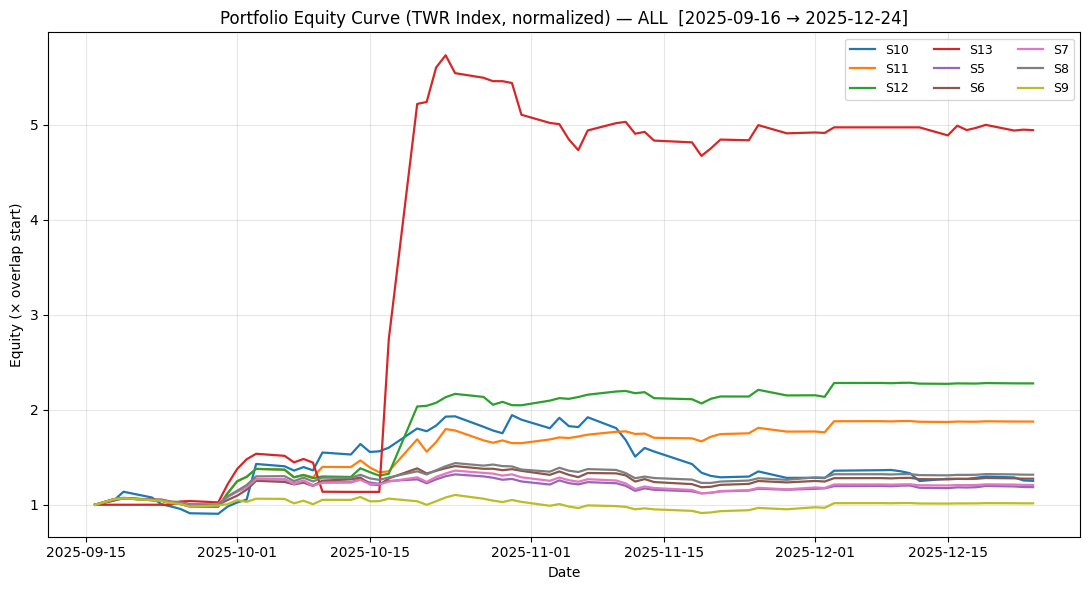

[all] wrote out\strat_metrics_all.csv


,strategy,cagr_pct,maxdd_pct,maxdd_mag_pct,calmar,final_equity
0,S10,128.72,-35.67,35.67,3.609,1.2514
1,S11,916.49,-8.59,8.59,106.754,1.8749
2,S12,1980.10,-8.26,8.26,239.702,2.2765
3,S13,36172.21,-26.11,26.11,1385.517,4.9404
4,S5,87.16,-15.18,15.18,5.743,1.1852
5,S6,144.35,-15.83,15.83,9.119,1.2740
6,S7,101.10,-17.53,17.53,5.768,1.2085
7,S8,175.47,-14.53,14.53,12.072,1.3161
8,S9,5.59,-17.25,17.25,0.324,1.0149


[all] saved out\cagr_maxdd_all.png
[all] saved out\figs\cagr_maxdd_all.png
[all] saved logs\out\figs\cagr_maxdd_all.png


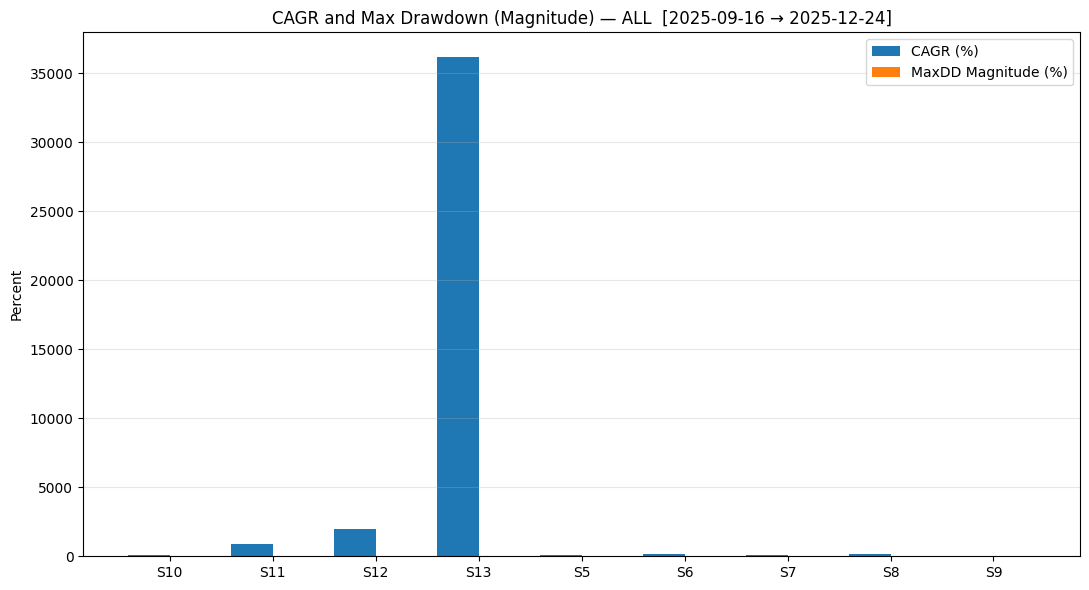


[select] strategy file spans:
  S10: rows=  66  span=2025-09-16 → 2025-12-24
  S11: rows=  66  span=2025-09-16 → 2025-12-24
  S12: rows=  66  span=2025-09-16 → 2025-12-24
  S13: rows=  66  span=2025-09-16 → 2025-12-24
   S5: rows=  66  span=2025-09-16 → 2025-12-24
   S6: rows=  66  span=2025-09-16 → 2025-12-24
   S7: rows=  66  span=2025-09-16 → 2025-12-24
   S8: rows=  66  span=2025-09-16 → 2025-12-24
   S9: rows=  66  span=2025-09-16 → 2025-12-24
[select] saved out\equity_curves_select.png
[select] saved out\figs\equity_curves_select.png
[select] saved logs\out\figs\equity_curves_select.png


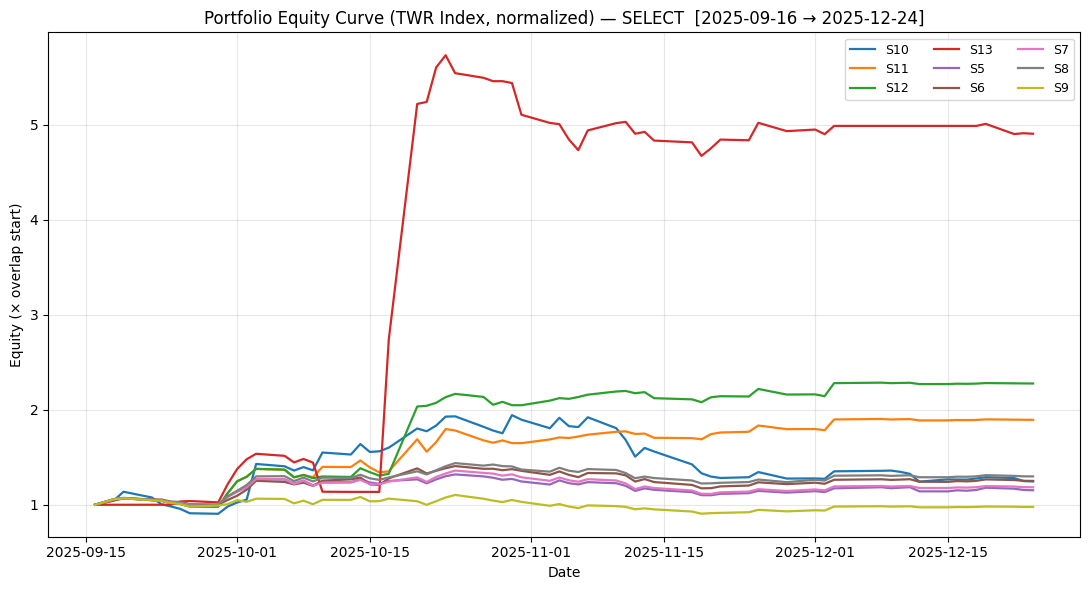

[select] wrote out\strat_metrics_select.csv


,strategy,cagr_pct,maxdd_pct,maxdd_mag_pct,calmar,final_equity
0,S10,124.53,-36.01,36.01,3.458,1.2451
1,S11,954.18,-8.59,8.59,111.145,1.8935
2,S12,1977.09,-8.26,8.26,239.337,2.2756
3,S13,35165.59,-26.11,26.11,1346.960,4.9029
4,S5,68.84,-16.62,16.62,4.143,1.1525
5,S6,128.25,-16.62,16.62,7.714,1.2507
6,S7,86.29,-18.03,18.03,4.787,1.1837
7,S8,161.84,-14.90,14.90,10.858,1.2981
8,S9,-8.29,-17.90,17.90,-0.463,0.9768


[select] saved out\cagr_maxdd_select.png
[select] saved out\figs\cagr_maxdd_select.png
[select] saved logs\out\figs\cagr_maxdd_select.png


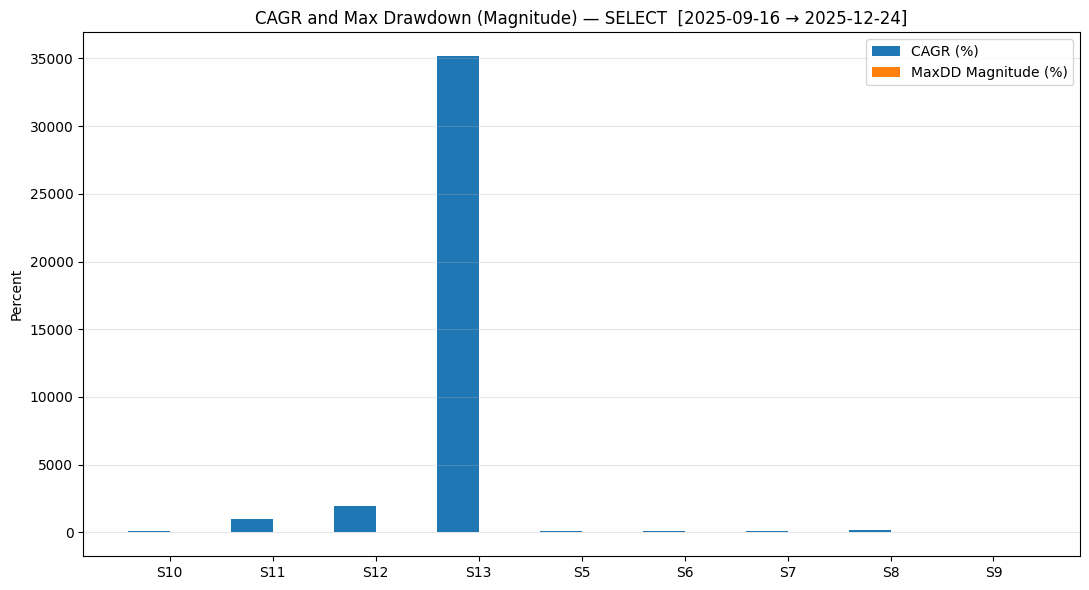

In [71]:
# --- Cell H (FULLY UPDATED v2): Equity curves + CAGR/MaxDD/Calmar charts (span-robust, auto-cohort) ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("./out")
FIGS = OUT / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

# Mirror location used by email_reports (logs/out/figs)
LOGS_OUT = Path("./logs") / "out"
LOGS_FIGS = LOGS_OUT / "figs"
LOGS_FIGS.mkdir(parents=True, exist_ok=True)

STRATS = ["S5","S6","S7","S8","S9","S10","S11","S12","S13"]


def _load_portfolios(tag: str) -> dict[str, pd.DataFrame]:
    dct: dict[str, pd.DataFrame] = {}
    for s in STRATS:
        p = OUT / f"strat_daily_portfolio_{s}_{tag}.csv"
        if not p.exists():
            continue

        df = pd.read_csv(p, parse_dates=["date"])
        if df.empty:
            continue
        df = df.sort_values("date").reset_index(drop=True)

        # Ensure equity_curve exists
        if "equity_curve" not in df.columns:
            if "twr_ret" in df.columns:
                tr = pd.to_numeric(df["twr_ret"], errors="coerce").fillna(0.0)
                df["equity_curve"] = (1.0 + tr).cumprod()
            else:
                continue

        df["equity_curve"] = pd.to_numeric(df["equity_curve"], errors="coerce")
        df = df.dropna(subset=["date","equity_curve"]).copy()

        # Dedup dates
        df = df.drop_duplicates(subset=["date"], keep="last").sort_values("date").reset_index(drop=True)

        dct[s] = df
    return dct


def _spans_df(pdict: dict[str, pd.DataFrame], tag: str) -> pd.DataFrame:
    rows = []
    for s, df in pdict.items():
        rows.append({
            "strategy": s,
            "rows": len(df),
            "start": pd.to_datetime(df["date"]).min(),
            "end": pd.to_datetime(df["date"]).max(),
        })
    sp = pd.DataFrame(rows).sort_values("strategy").reset_index(drop=True)
    print(f"\n[{tag}] strategy file spans:")
    if len(sp):
        for _, r in sp.iterrows():
            print(f"  {r['strategy']:>3}: rows={int(r['rows']):4d}  span={r['start'].date()} → {r['end'].date()}")
    return sp


def _choose_best_overlap_cohort(spans: pd.DataFrame) -> tuple[list[str], pd.Timestamp, pd.Timestamp]:
    """
    Choose the largest set of strategies that share a non-empty overlap window.
    Greedy heuristic: try each strategy's start as candidate overlap start; include all
    strategies whose span covers that start, then compute overlap end.
    """
    if spans.empty:
        return [], pd.NaT, pd.NaT

    best = ([], pd.NaT, pd.NaT, -1)  # (cohort, start, end, cohort_size)

    # candidate starts: each strategy start (sorted)
    cand_starts = sorted(spans["start"].dropna().unique())
    for s0 in cand_starts:
        covered = spans[(spans["start"] <= s0) & (spans["end"] >= s0)].copy()
        if covered.empty:
            continue
        end = covered["end"].min()
        if pd.isna(end) or s0 > end:
            continue
        cohort = covered["strategy"].tolist()
        if len(cohort) > best[3]:
            best = (cohort, s0, end, len(cohort))

    return best[0], best[1], best[2]


def _restrict_and_normalize(pdict: dict[str, pd.DataFrame], cohort: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    out = {}
    for s in cohort:
        df = pdict[s]
        d = df[(df["date"] >= start) & (df["date"] <= end)].copy()
        d = d.sort_values("date").reset_index(drop=True)
        if len(d) == 0:
            continue
        # normalize to 1.0 at overlap start
        base = float(d.loc[0, "equity_curve"])
        if not np.isfinite(base) or base == 0:
            continue
        d["equity_curve"] = d["equity_curve"] / base
        out[s] = d
    return out


def _merge_equity_curves(pdict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    curves = None
    for s, df in pdict.items():
        col = df[["date","equity_curve"]].rename(columns={"equity_curve": s})
        curves = col if curves is None else curves.merge(col, on="date", how="outer")
    if curves is None:
        return pd.DataFrame()
    return curves.sort_values("date").reset_index(drop=True)


def _cagr(eq: pd.Series, dates: pd.Series) -> float:
    eq = pd.to_numeric(eq, errors="coerce")
    if eq.dropna().empty:
        return np.nan
    start = pd.to_datetime(dates.iloc[0])
    end   = pd.to_datetime(dates.iloc[-1])
    years = max((end - start).days, 1) / 365.25
    eq0 = float(eq.iloc[0]); eq1 = float(eq.iloc[-1])
    if not np.isfinite(eq0) or not np.isfinite(eq1) or eq0 <= 0:
        return np.nan
    return (eq1 / eq0) ** (1.0 / years) - 1.0


def _maxdd(eq: pd.Series) -> float:
    eq = pd.to_numeric(eq, errors="coerce")
    if eq.dropna().empty:
        return np.nan
    runmax = eq.cummax()
    dd = eq / runmax - 1.0
    return float(dd.min())


def _metrics_table(pdict: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for s, df in pdict.items():
        eq = df["equity_curve"].astype(float)
        dt = df["date"]
        c = _cagr(eq, dt)
        m = _maxdd(eq)
        m_mag = (-m) if np.isfinite(m) else np.nan
        calmar = (c / m_mag) if (np.isfinite(c) and np.isfinite(m_mag) and m_mag > 1e-12) else np.nan
        rows.append({
            "strategy": s,
            "cagr": c,
            "maxdd": m,          # negative
            "maxdd_mag": m_mag,  # positive
            "calmar": calmar,
            "final_equity": float(eq.iloc[-1]) if len(eq) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("strategy").reset_index(drop=True)


def _plot_equity_curves(curves: pd.DataFrame, tag: str, start: pd.Timestamp, end: pd.Timestamp):
    if curves.empty:
        print(f"[{tag}] No curves to plot.")
        return
    plt.figure(figsize=(11, 6))
    for s in [c for c in curves.columns if c != "date"]:
        plt.plot(curves["date"], curves[s], label=s, linewidth=1.6)
    plt.title(f"Portfolio Equity Curve (TWR Index, normalized) — {tag.upper()}  [{start.date()} → {end.date()}]")
    plt.xlabel("Date")
    plt.ylabel("Equity (× overlap start)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=9)

    # Save in three places:
    #   - ./out/equity_curves_<tag>.png      (flat out folder)
    #   - ./out/figs/equity_curves_<tag>.png (figs subfolder)
    #   - ./logs/out/figs/equity_curves_<tag>.png (for email_reports LOGS_FIGS_DIR)
    out_paths = [
        OUT / f"equity_curves_{tag}.png",
        FIGS / f"equity_curves_{tag}.png",
        LOGS_FIGS / f"equity_curves_{tag}.png",
    ]

    plt.tight_layout()
    for path in out_paths:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=140)
        print(f"[{tag}] saved {path}")
    plt.show()


def _plot_cagr_maxdd(met: pd.DataFrame, tag: str, start: pd.Timestamp, end: pd.Timestamp):
    if met.empty:
        print(f"[{tag}] No metrics to plot.")
        return
    idx = np.arange(len(met))
    width = 0.4
    plt.figure(figsize=(11, 6))
    plt.bar(idx - width/2, 100.0 * met["cagr"], width, label="CAGR (%)")
    plt.bar(idx + width/2, 100.0 * met["maxdd_mag"], width, label="MaxDD Magnitude (%)")
    plt.xticks(idx, met["strategy"])
    plt.title(f"CAGR and Max Drawdown (Magnitude) — {tag.upper()}  [{start.date()} → {end.date()}]")
    plt.ylabel("Percent")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()

    out_paths = [
        OUT / f"cagr_maxdd_{tag}.png",
        FIGS / f"cagr_maxdd_{tag}.png",
        LOGS_FIGS / f"cagr_maxdd_{tag}.png",
    ]

    plt.tight_layout()
    for path in out_paths:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=140)
        print(f"[{tag}] saved {path}")
    plt.show()


def run_charts(tag: str):
    pdict = _load_portfolios(tag)
    if not pdict:
        print(f"[{tag}] No strategy files found.")
        return

    spans = _spans_df(pdict, tag)

    # pick best overlapping cohort
    cohort, start, end = _choose_best_overlap_cohort(spans)

    if not cohort or pd.isna(start) or pd.isna(end) or start > end:
        print(f"[{tag}] No overlapping cohort found. You have fully disjoint output files.")
        print(f"[{tag}] Fix: delete ./out/strat_daily_portfolio_*_{tag}.csv and rerun Cell F.")
        return

    excluded = sorted(set(spans["strategy"].tolist()) - set(cohort))
    if excluded:
        print(f"[{tag}] WARNING: plotting only the largest overlapping cohort ({len(cohort)} strategies).")
        print(f"[{tag}] Excluded (no overlap): {excluded}")
        print(f"[{tag}] Overlap window used: {start.date()} → {end.date()}")

    pdict2 = _restrict_and_normalize(pdict, cohort, start, end)

    curves = _merge_equity_curves(pdict2)
    _plot_equity_curves(curves, tag, start, end)

    met = _metrics_table(pdict2)
    out_csv = OUT / f"strat_metrics_{tag}.csv"
    met.to_csv(out_csv, index=False)
    print(f"[{tag}] wrote {out_csv}")

    display(
        met.assign(
            cagr_pct=(100*met["cagr"]).round(2),
            maxdd_pct=(100*met["maxdd"]).round(2),
            maxdd_mag_pct=(100*met["maxdd_mag"]).round(2),
            calmar=met["calmar"].round(3),
            final_equity=met["final_equity"].round(4),
        )[["strategy","cagr_pct","maxdd_pct","maxdd_mag_pct","calmar","final_equity"]]
    )

    _plot_cagr_maxdd(met, tag, start, end)


# ----- Run for ALL and (if present) SELECT -----
run_charts("all")

if any((OUT / f"strat_daily_portfolio_{s}_select.csv").exists() for s in STRATS):
    run_charts("select")
else:
    print("[select] No SELECT strategy files found; skipped.")


In [59]:
# --- Cell: daily per-symbol % from base + append TODAY infer plan ---
from pathlib import Path
import numpy as np
import pandas as pd
import re

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

STRATS = ["BH","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"]
POOLED = {"S3","S4","S5","S6","S7","S8","S9","S10","S11","S12","S13"}

SEQUESTERED = {"S2"}

PCT_COLS_FULL = [
    "pct_BH","pct_S2",
    "pct_S3","pct_S4","pct_S5","pct_S6","pct_S7","pct_S8","pct_S9","pct_S10","pct_S11","pct_S12","pct_S13"
]
ACC_MIN_SAMPLES = 20
EPS = 1e-9

# ------------------- helpers: load select universe (optional) -------------------
def _load_select_symbols() -> set:
    if "SELECT_SYMBOLS" in globals():
        try:
            return {str(s).strip().upper() for s in SELECT_SYMBOLS if str(s).strip()}
        except Exception:
            pass
    f = Path("./universe/select_symbols.txt")
    if f.exists():
        toks = re.split(r"[,\s]+", f.read_text(encoding="utf-8").strip())
        return {t.strip().upper() for t in toks if t.strip()}
    return set()

def _score_to_weight(score: pd.Series) -> pd.Series:
    s = pd.to_numeric(score, errors="coerce")
    w = 1.0 + 0.5 * np.clip((s - 0.5) / 0.4, -1, 1)  # rough map to 0.5x..1.5x
    return w.fillna(1.0)

# ------------------- HISTORICAL % from base + per-symbol strategy files -------------------
def _load_per_symbol(strategy: str, tag: str) -> pd.DataFrame | None:
    p = OUT / f"strat_daily_per_symbol_{strategy}_{tag}.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p, parse_dates=["date"])
    d["symbol"] = d["symbol"].astype(str)
    return d

def _history_pcts_for_tag(tag: str, base_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Build one table with daily per-symbol % for all strategies (BH,S2..S10)
    based on historical runs (no today).
    """
    b = base_slice.copy()
    b["date"] = pd.to_datetime(b["date"])
    b["symbol"] = b["symbol"].astype(str)
    b = b.sort_values(["symbol","date"])

    # master key from base
    key = b[["date","symbol"]].drop_duplicates().sort_values(["date","symbol"]).reset_index(drop=True)

    # --- BH from base (equal-weight drift with bh_ret) ---
    df_bh = b.copy()
    df_bh["bh_val"] = (
        df_bh.groupby("symbol")["bh_ret"]
             .apply(lambda s: (1.0 + s.fillna(0.0)).cumprod())
             .reset_index(level=0, drop=True)
    )
    denom = df_bh.groupby("date", as_index=False)["bh_val"].sum().rename(columns={"bh_val":"bh_total"})
    df_bh = df_bh.merge(denom, on="date", how="left")
    df_bh["pct_BH"] = np.where(df_bh["bh_total"] > 0, df_bh["bh_val"] / df_bh["bh_total"], 0.0)
    hist = key.merge(df_bh[["date","symbol","pct_BH"]], on=["date","symbol"], how="left")

    # --- S2..S9 from per-symbol strategy outputs ---
    for strat in STRATS:
        if strat == "BH":
            continue
        d = _load_per_symbol(strat, tag)
        col = f"pct_{strat}"
        if d is None or d.empty:
            hist[col] = 0.0
            continue

        if strat in POOLED:
            eq = pd.to_numeric(d["invested_after"], errors="coerce").fillna(0.0)
        elif strat in SEQUESTERED:
            eq = (
                pd.to_numeric(d["invested_after"], errors="coerce").fillna(0.0)
                + pd.to_numeric(d["cash_after"], errors="coerce").fillna(0.0)
            )
        else:
            hist[col] = 0.0
            continue

        d2 = d.assign(equity_sym=eq)
        denom2 = d2.groupby("date", as_index=False)["equity_sym"].sum().rename(columns={"equity_sym":"equity_total"})
        d2 = d2.merge(denom2, on="date", how="left")
        d2[col] = np.where(d2["equity_total"] > 0, d2["equity_sym"] / d2["equity_total"], 0.0)
        d2 = d2[["date","symbol",col]]
        d2["date"] = pd.to_datetime(d2["date"])
        d2["symbol"] = d2["symbol"].astype(str)

        hist = hist.merge(d2, on=["date","symbol"], how="left")

    # ensure all pct columns exist & numeric
    for c in PCT_COLS_FULL:
        if c not in hist.columns:
            hist[c] = 0.0
        hist[c] = pd.to_numeric(hist[c], errors="coerce").fillna(0.0)

    hist["note"] = "history"
    hist = hist.sort_values(["date","symbol"]).reset_index(drop=True)
    return hist[["date","symbol"] + PCT_COLS_FULL + ["note"]]

# ------------------- TODAY plan from today_inf + base -------------------
def _eligibility_from_base(base_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Compute prior realized TWR metrics for S8/S9 gating, counts for S6/S7 ramp,
    and S11 activation state + active age, using only info up to the last
    row in `base_slice`.
    """
    if base_slice.empty:
        return pd.DataFrame(
            columns=[
                "symbol",
                "twr_cum_prior","twr_roll10_prior",
                "elig_s8","elig_s9",
                "n_seen_prior",
                "elig_s11","active_age_s11",
            ]
        )

    ev = base_slice.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev["symbol"] = ev["symbol"].astype(str)
    ev = ev.sort_values(["symbol", "date"])
    grp = ev.groupby("symbol", sort=False)

    # --- cumulative realized TWR up to each row, then shifted to be PRIOR (S8) ---
    cum_twr = grp["realized_ret"].transform(
        lambda s: (1.0 + s.fillna(0.0)).cumprod()
    )
    ev["twr_cum_prior"] = cum_twr.shift(1) - 1.0

    # --- rolling-10 realized TWR up to each row, then shifted to be PRIOR (S9) ---
    def _twr_roll10(s: pd.Series) -> pd.Series:
        vals = (1.0 + s.fillna(0.0)).rolling(window=10, min_periods=10).apply(
            lambda x: float(np.prod(x) - 1.0), raw=True
        )
        return vals

    roll10 = grp["realized_ret"].transform(_twr_roll10)
    ev["twr_roll10_prior"] = roll10.shift(1)

    # latest prior info per symbol
    prior = (
        ev.sort_values(["symbol", "date"])
          .groupby("symbol", as_index=False)
          .tail(1)[["symbol", "twr_cum_prior", "twr_roll10_prior"]]
    )

    prior["elig_s8"] = (prior["twr_cum_prior"] >= -EPS)
    prior["elig_s9"] = (prior["twr_roll10_prior"] > EPS)

    # count of seen rows per symbol (for S6/S7 ramp)
    cnt = base_slice.groupby("symbol", as_index=False).size().rename(columns={"size": "n_seen_prior"})
    prior = prior.merge(cnt, on="symbol", how="outer").fillna({"n_seen_prior": 0})

    # --- S11: final activation + active age as of end of base_slice ---
    if "correct" in ev.columns:
        ev["side"] = ev["side"].astype(str).str.upper()
        ev["is_buy"] = ev["side"].eq("BUY")
        ev["is_sell"] = ev["side"].eq("SELL")
        ev["is_hold"] = ev["side"].eq("HOLD")

        records = []
        for sym, df_sym in ev.groupby("symbol", sort=False):
            active = False
            good_streak = 0
            bad_streak = 0
            age = 0.0

            for _, row in df_sym.iterrows():
                is_signal = bool(row["is_buy"]) or bool(row["is_sell"])
                if not is_signal:
                    if active:
                        age += 1.0
                    continue

                is_corr = bool(row["correct"])
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0

                if active:
                    age += 1.0

            records.append({"symbol": sym, "elig_s11": active, "active_age_s11": age})

        s11_df = pd.DataFrame.from_records(records)
        prior = prior.merge(s11_df, on="symbol", how="left")
    else:
        prior["elig_s11"] = False
        prior["active_age_s11"] = 0.0

    prior["elig_s11"] = prior["elig_s11"].fillna(False)
    prior["active_age_s11"] = prior["active_age_s11"].fillna(0.0)
    prior["symbol"] = prior["symbol"].astype(str)
    return prior

def _normalize_today(today_df: pd.DataFrame) -> pd.DataFrame:
    ev = today_df.copy()
    ev["date"] = pd.to_datetime(ev["date"])
    ev["symbol"] = ev["symbol"].astype(str)

    # Default model_kind for old logs that don't have it
    if "model_kind" not in ev.columns:
        ev["model_kind"] = "general"

    ev["side"] = ev["side"].astype(str).str.upper()

    if "pos_frac" not in ev.columns:
        ev["pos_frac"] = 1.0
    if "score" not in ev.columns:
        ev["score"] = np.nan

    ev["dyn_weight_base"] = _score_to_weight(ev["score"])
    ev["is_buy"]  = ev["side"].eq("BUY")
    ev["is_hold"] = ev["side"].eq("HOLD")
    ev["is_sell"] = ev["side"].eq("SELL")

    return ev.sort_values(["symbol"]).reset_index(drop=True)


def _weights_for_strategy_today(ev0: pd.DataFrame, strat: str) -> pd.DataFrame:
    """
    Return DF [symbol, pct_<strat>] where weights sum to 1 if any symbols present.
    Uses today_inf info + prior info from base for S6/S7/S8/S9 and OOS RL metrics for S10,
    plus S11 activation/age for S11.
    """
    df = ev0.copy()
    df["symbol"] = df["symbol"].astype(str)

    if strat == "S10":
        s10_w = load_s10_train_weights()
        if not s10_w:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        df = df[df["symbol"].str.upper().isin(s10_w.keys())].copy()
        if df.empty:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        w = df["pos_frac"].clip(lower=0.0).astype(float)
        c = df["symbol"].str.upper().map(s10_w).astype(float)
        w = w * c

    elif strat == "S11":
        # Only ACTIVE models participate in S11, with seniority boost.
        df = df[df["elig_s11"].fillna(False)].copy()
        if df.empty:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])
        w = df["pos_frac"].clip(lower=0.0).astype(float)
        age = df.get("active_age_s11")
        if age is None:
            age = 0.0
        else:
            age = age.fillna(0.0).astype(float)
        age = np.clip(age, 0.0, S11_AGE_CAP)
        mult = 1.0 + age / S11_AGE_DIV
        w = w * mult

    else:
        w = df["pos_frac"].clip(lower=0.0).astype(float)

        if strat in {"S5","S6","S7","S8","S9"}:
            w = w * df["dyn_weight_base"].astype(float)

        if strat in {"S6","S7"}:
            ramp = np.minimum(
                1.0,
                df["n_seen_prior"].fillna(0).astype(float) / float(ACC_MIN_SAMPLES)
            )
            w = w * ramp

        if strat == "S8":
            w = w * df["elig_s8"].fillna(False).astype(float)
        elif strat == "S9":
            w = w * df["elig_s9"].fillna(False).astype(float)

    # Prefer BUYs, otherwise HOLDs, otherwise equal-weight
    w = np.where(df["is_buy"], w, 0.0)
    total = float(np.nansum(w))
    if total > 0:
        w = w / total
    else:
        if df["is_hold"].any():
            mask = df["is_hold"].values
            w = np.zeros(len(df), dtype=float)
            if mask.sum() > 0:
                w[mask] = 1.0 / mask.sum()
        elif len(df) > 0:
            w = np.full(len(df), 1.0 / len(df), dtype=float)
        else:
            return pd.DataFrame(columns=["symbol", f"pct_{strat}"])

    wdf = pd.DataFrame({"symbol": df["symbol"].values, f"pct_{strat}": w})
    wdf = wdf.groupby("symbol", as_index=False).sum()
    wdf["symbol"] = wdf["symbol"].astype(str)
    return wdf


def _today_pcts_for_tag(tag: str, base_slice: pd.DataFrame, today_slice: pd.DataFrame) -> pd.DataFrame:
    """
    Build today's per-symbol % for each strategy:
      - BH/S2: 0 (we don't re-allocate them off today's infer)
      - S3..S9: BUY-weighted with score/evidence/gates
    """
    if today_slice.empty:
        return pd.DataFrame(columns=["date","symbol"] + PCT_COLS_FULL + ["note"])

    prior = _eligibility_from_base(base_slice)
    ev0 = _normalize_today(today_slice).merge(prior, on="symbol", how="left")
    ev0["n_seen_prior"] = ev0["n_seen_prior"].fillna(0)

    # --- general vs bear priority on BUYs ---
    # If both general and bear are active & BUY for same symbol/day, keep general.
    if "model_kind" in ev0.columns:
        buy = ev0[ev0["side"].str.upper().eq("BUY")].copy()
        other = ev0[~ev0["side"].str.upper().eq("BUY")].copy()

        if not buy.empty:
            priority = pd.CategoricalDtype(["general", "bear"], ordered=True)
            buy["model_kind"] = buy["model_kind"].astype(priority)

            buy = (
                buy
                .sort_values(["date", "symbol", "model_kind"])
                .groupby(["date", "symbol"], as_index=False)
                .head(1)
            )

        ev0 = pd.concat([buy, other], ignore_index=True)

    out = ev0[["date","symbol"]].drop_duplicates().reset_index(drop="index")

    # S3..S9 pooled strategies
    for strat in sorted(list(POOLED)):
        wdf = _weights_for_strategy_today(ev0, strat)
        col = f"pct_{strat}"
        out = out.merge(wdf, on="symbol", how="left")
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    # BH & S2 are not sized from today's infer → 0
    out["pct_BH"] = 0.0
    out["pct_S2"] = 0.0

    # ensure all pct cols present & in order
    for c in PCT_COLS_FULL:
        if c not in out.columns:
            out[c] = 0.0
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0).clip(0.0, 1.0)

    out["note"] = "today_plan"
    out["date"] = pd.to_datetime(out["date"])
    out["symbol"] = out["symbol"].astype(str)

    # small sanity check: per-strategy sums ≈ 1
    sums = {c: float(out[c].sum()) for c in PCT_COLS_FULL if c not in {"pct_BH","pct_S2"}}
    print(f"[{tag}] today strategy sums:", {k: round(v, 6) for k, v in sums.items()})

    return out[["date","symbol"] + PCT_COLS_FULL + ["note"]].sort_values(["date","symbol"]).reset_index(drop=True)

# ------------------- build ALL + SELECT tables -------------------
assert "base" in globals() and "today_inf" in globals(), "Run the revised Cell D first."

# ALL
hist_all = _history_pcts_for_tag("all", base)
today_all = _today_pcts_for_tag("all", base, today_inf)
alloc_all = pd.concat([hist_all, today_all], ignore_index=True, sort=False)
alloc_all = alloc_all.sort_values(["date","symbol"]).reset_index(drop=True)

path_all = OUT / "alloc_percent_all_with_today.csv"
alloc_all.to_csv(path_all, index=False)
print(f"[ALL] wrote {path_all}  ({len(alloc_all):,} rows)")
display(alloc_all.tail(15))

# SELECT (if configured)
select_set = _load_select_symbols()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    today_sel = today_inf[today_inf["symbol"].isin(select_set)].copy()
    hist_sel = _history_pcts_for_tag("select", base_sel)
    today_sel_tbl = _today_pcts_for_tag("select", base_sel, today_sel)
    alloc_sel = pd.concat([hist_sel, today_sel_tbl], ignore_index=True, sort=False)
    alloc_sel = alloc_sel.sort_values(["date","symbol"]).reset_index(drop=True)
    path_sel = OUT / "alloc_percent_select_with_today.csv"
    alloc_sel.to_csv(path_sel, index=False)
    print(f"[SELECT] wrote {path_sel}  ({len(alloc_sel):,} rows)")
    display(alloc_sel.tail(15))
else:
    print("[SELECT] No SELECT_SYMBOLS configured; only wrote ALL.")


[all] today strategy sums: {'pct_S3': 1.0, 'pct_S4': 1.0, 'pct_S5': 1.0, 'pct_S6': 1.0, 'pct_S7': 1.0, 'pct_S8': 1.0, 'pct_S9': 1.0, 'pct_S10': 1.0, 'pct_S11': 1.0, 'pct_S12': 1.0, 'pct_S13': 1.0}
[ALL] wrote out\alloc_percent_all_with_today.csv  (10,075,637 rows)


,date,symbol,pct_BH,pct_S2,pct_S3,pct_S4,pct_S5,pct_S6,pct_S7,pct_S8,pct_S9,pct_S10,pct_S11,pct_S12,pct_S13,note
10075622,2025-12-26,TRI,0.0,0.0,0.007605,0.007605,0.007605,0.007605,0.007605,0.015038,0.013699,0.0,0.000000,0.007605,0.007605,today_plan
10075623,2025-12-26,TRV,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,today_plan
10075624,2025-12-26,TSM,0.0,0.0,0.007605,0.007605,0.007605,0.007605,0.007605,0.015038,0.013699,0.0,0.000000,0.007605,0.007605,today_plan
10075625,2025-12-26,TTD,0.0,0.0,0.007605,0.007605,0.007605,0.007605,0.007605,0.000000,0.000000,0.0,0.000000,0.007605,0.007605,today_plan
10075626,2025-12-26,TTWO,0.0,0.0,0.007605,0.007605,0.007605,0.007605,0.007605,0.015038,0.013699,0.0,0.057942,0.007605,0.007605,today_plan
10075627,2025-12-26,TXN,0.0,0.0,0.015209,0.015209,0.015209,0.015209,0.015209,0.030075,0.000000,0.0,0.000000,0.015209,0.015209,today_plan
10075628,2025-12-26,VICR,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,today_plan
10075629,2025-12-26,VRSK,0.0,0.0,0.015209,0.015209,0.015209,0.015209,0.015209,0.000000,0.000000,0.0,0.000000,0.015209,0.015209,today_plan
10075630,2025-12-26,VRTX,0.0,0.0,0.007605,0.007605,0.007605,0.007605,0.007605,0.015038,0.013699,0.0,0.000000,0.007605,0.007605,today_plan
10075631,2025-12-26,VZ,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,today_plan


[select] today strategy sums: {'pct_S3': 1.0, 'pct_S4': 1.0, 'pct_S5': 1.0, 'pct_S6': 1.0, 'pct_S7': 1.0, 'pct_S8': 1.0, 'pct_S9': 1.0, 'pct_S10': 1.0, 'pct_S11': 1.0, 'pct_S12': 1.0, 'pct_S13': 1.0}
[SELECT] wrote out\alloc_percent_select_with_today.csv  (4,774,225 rows)


,date,symbol,pct_BH,pct_S2,pct_S3,pct_S4,pct_S5,pct_S6,pct_S7,pct_S8,pct_S9,pct_S10,pct_S11,pct_S12,pct_S13,note
4774210,2025-12-26,RGTI,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,today_plan
4774211,2025-12-26,RMBS,0.0,0.0,0.018519,0.018519,0.018519,0.018519,0.018519,0.00000,0.000000,0.0,0.0,0.018519,0.018519,today_plan
4774212,2025-12-26,RNW,0.0,0.0,0.027778,0.027778,0.027778,0.027778,0.027778,0.00000,0.048387,0.0,0.0,0.027778,0.027778,today_plan
4774213,2025-12-26,ROP,0.0,0.0,0.018519,0.018519,0.018519,0.018519,0.018519,0.00000,0.000000,0.0,0.0,0.018519,0.018519,today_plan
4774214,2025-12-26,SEDG,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,today_plan
4774215,2025-12-26,SLDP,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,today_plan
4774216,2025-12-26,SMCI,0.0,0.0,0.018519,0.018519,0.018519,0.018519,0.018519,0.00000,0.000000,0.0,0.0,0.018519,0.018519,today_plan
4774217,2025-12-26,SNOW,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,today_plan
4774218,2025-12-26,TDC,0.0,0.0,0.018519,0.018519,0.018519,0.018519,0.018519,0.04878,0.032258,0.0,0.0,0.018519,0.018519,today_plan
4774219,2025-12-26,TM,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,today_plan


In [60]:
# --- Cell G: Gating audit view (stream-aware) for S8/S9/S11/S12/S13 ---
from pathlib import Path
import numpy as np
import pandas as pd

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

# Requires: _prep_ev, _eligibility_columns, and parameters like EPS, S11_*, S12_* from Cell F
# Also expects: base exists (from Cell D)

def _trace_s11(ev: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute S11 activation logic per stream_id and return a per-row trace with:
      - pre_active/pre_age (state prior to this row's outcome; matches elig_s11 intent)
      - post_active/post_age
      - counters + event/reason
    """
    rows = []
    for sid, df_sid in ev.sort_values(["stream_id","date"]).groupby("stream_id", sort=False):
        active = False
        good_streak = 0
        bad_streak = 0
        age = 0.0

        for idx, row in df_sid.iterrows():
            is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
            is_corr = bool(row.get("correct", False))

            pre_active, pre_age = active, age
            pre_good, pre_bad = good_streak, bad_streak
            event, reason = "", ""

            if not is_signal:
                # HOLD: does not change streaks; if active, time passes
                if active:
                    age += 1.0
            else:
                if is_corr:
                    good_streak += 1
                    bad_streak = 0
                    if (not active) and good_streak >= S11_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        event = "activate"
                        reason = f"good_streak {good_streak} >= {S11_ACTIVATION_GOOD}"
                else:
                    bad_streak += 1
                    good_streak = 0
                    if active and bad_streak >= S11_DEACTIVATION_BAD:
                        active = False
                        age = 0.0
                        event = "deactivate"
                        reason = f"bad_streak {bad_streak} >= {S11_DEACTIVATION_BAD}"

                if active:
                    age += 1.0

            rows.append({
                "idx": idx,
                "s11_pre_active": pre_active,
                "s11_pre_age": pre_age,
                "s11_pre_good": pre_good,
                "s11_pre_bad": pre_bad,
                "s11_post_active": active,
                "s11_post_age": age,
                "s11_post_good": good_streak,
                "s11_post_bad": bad_streak,
                "s11_event": event,
                "s11_reason": reason,
            })

    tr = pd.DataFrame(rows).set_index("idx").sort_index()
    return tr


def _trace_s12(ev: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute S12 activation logic per stream_id and return a per-row trace with:
      - pre_active/pre_age (state prior to this row's outcome; matches elig_s12 intent)
      - post_active/post_age
      - counters + event/reason
    """
    rows = []
    for sid, df_sid in ev.sort_values(["stream_id","date"]).groupby("stream_id", sort=False):
        active = False
        good_streak = 0
        wrong_since_activation = 0
        age = 0.0

        for idx, row in df_sid.iterrows():
            is_signal = bool(row.get("is_buy", False)) or bool(row.get("is_sell", False))
            is_corr = bool(row.get("correct", False))

            pre_active, pre_age = active, age
            pre_good, pre_wrong = good_streak, wrong_since_activation
            event, reason = "", ""

            if not is_signal:
                if active:
                    age += 1.0
            else:
                if is_corr:
                    good_streak += 1
                    if (not active) and good_streak >= S12_ACTIVATION_GOOD:
                        active = True
                        age = 0.0
                        wrong_since_activation = 0
                        event = "activate"
                        reason = f"good_streak {good_streak} >= {S12_ACTIVATION_GOOD}"
                else:
                    good_streak = 0
                    if active:
                        wrong_since_activation += 1
                        if wrong_since_activation >= S12_DEACTIVATION_BAD:
                            active = False
                            age = 0.0
                            wrong_since_activation = 0
                            event = "deactivate"
                            reason = f"wrongs_since_activation {pre_wrong+1} >= {S12_DEACTIVATION_BAD}"

                if active:
                    age += 1.0

            rows.append({
                "idx": idx,
                "s12_pre_active": pre_active,
                "s12_pre_age": pre_age,
                "s12_pre_good": pre_good,
                "s12_pre_wrong": pre_wrong,
                "s12_post_active": active,
                "s12_post_age": age,
                "s12_post_good": good_streak,
                "s12_post_wrong": wrong_since_activation,
                "s12_event": event,
                "s12_reason": reason,
            })

    tr = pd.DataFrame(rows).set_index("idx").sort_index()
    return tr


def build_gating_views(base_df: pd.DataFrame, tag: str):
    """
    Build and write:
      - gating_audit_{tag}.csv  (long-form per (date, stream_id, strategy))
      - gating_events_{tag}.csv (S11/S12 activate/deactivate events)
      - gating_counts_{tag}.csv (daily gated-in counts per strategy)
    """
    if base_df.empty:
        print(f"[{tag}] empty base slice; skipping gating views.")
        return (pd.DataFrame(), pd.DataFrame(), pd.DataFrame())

    ev = _prep_ev(base_df)
    ev = _eligibility_columns(ev)

    # Traces for “why” on state machines
    tr11 = _trace_s11(ev) if "correct" in ev.columns else pd.DataFrame(index=ev.index)
    tr12 = _trace_s12(ev) if "correct" in ev.columns else pd.DataFrame(index=ev.index)

    ev2 = ev.copy()
    ev2 = ev2.join(tr11, how="left").join(tr12, how="left")

    # Base columns for audit
    base_cols = ["date","stream_id","symbol","side","ret_next","pos_frac"]
    if "model_kind" in ev2.columns:
        base_cols.append("model_kind")
    if "correct" in ev2.columns:
        base_cols.append("correct")

    # Long-form audit rows
    rows = []

    def _add_rows(strategy: str, gated_in: pd.Series, why: pd.Series, extra: dict = None):
        extra = extra or {}
        for i in ev2.index:
            r = ev2.loc[i, base_cols].to_dict()
            r.update({
                "strategy": strategy,
                "gated_in": bool(gated_in.loc[i]) if i in gated_in.index else False,
                "why": str(why.loc[i]) if i in why.index else "",
            })
            for k, v in extra.items():
                # v can be a scalar or a Series aligned to ev2 index
                if isinstance(v, pd.Series):
                    r[k] = v.loc[i] if i in v.index else np.nan
                else:
                    r[k] = v
            rows.append(r)

    # --- S8 gating ---
    if "elig_s8" in ev2.columns:
        val = ev2.get("twr_cum_prior", pd.Series(index=ev2.index, dtype=float))
        why = val.apply(lambda x: f"twr_cum_prior={x:.6f} >= {-EPS:.6g}" if pd.notna(x) else "twr_cum_prior=NA")
        _add_rows(
            "S8",
            gated_in=ev2["elig_s8"].fillna(False),
            why=why,
            extra={"twr_cum_prior": val}
        )

    # --- S9 gating ---
    if "elig_s9" in ev2.columns:
        val = ev2.get("twr_roll10_prior", pd.Series(index=ev2.index, dtype=float))
        why = val.apply(lambda x: f"twr_roll10_prior={x:.6f} > {EPS:.6g}" if pd.notna(x) else "twr_roll10_prior=NA")
        _add_rows(
            "S9",
            gated_in=ev2["elig_s9"].fillna(False),
            why=why,
            extra={"twr_roll10_prior": val}
        )

    # --- S11 gating (state machine) ---
    if "s11_pre_active" in ev2.columns:
        gated = ev2["s11_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            if bool(gated.loc[i]):
                why.loc[i] = f"active (age={ev2.at[i,'s11_pre_age']:.0f})"
            else:
                g = ev2.at[i, "s11_pre_good"] if pd.notna(ev2.at[i, "s11_pre_good"]) else 0
                b = ev2.at[i, "s11_pre_bad"] if pd.notna(ev2.at[i, "s11_pre_bad"]) else 0
                why.loc[i] = f"inactive (good_streak={int(g)}, bad_streak={int(b)})"
            evnt = str(ev2.at[i, "s11_event"]) if pd.notna(ev2.at[i, "s11_event"]) else ""
            rsn  = str(ev2.at[i, "s11_reason"]) if pd.notna(ev2.at[i, "s11_reason"]) else ""
            if evnt:
                why.loc[i] += f" | event={evnt} ({rsn})"

        _add_rows(
            "S11",
            gated_in=gated,
            why=why,
            extra={
                "s11_pre_active": ev2["s11_pre_active"],
                "s11_pre_age": ev2["s11_pre_age"],
                "s11_pre_good": ev2["s11_pre_good"],
                "s11_pre_bad": ev2["s11_pre_bad"],
                "s11_event": ev2["s11_event"],
                "s11_reason": ev2["s11_reason"],
            }
        )

    # --- S12 gating (state machine) ---
    if "s12_pre_active" in ev2.columns:
        gated = ev2["s12_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            if bool(gated.loc[i]):
                why.loc[i] = f"active (age={ev2.at[i,'s12_pre_age']:.0f}, wrongs={int(ev2.at[i,'s12_pre_wrong']) if pd.notna(ev2.at[i,'s12_pre_wrong']) else 0})"
            else:
                g = ev2.at[i, "s12_pre_good"] if pd.notna(ev2.at[i, "s12_pre_good"]) else 0
                why.loc[i] = f"inactive (good_streak={int(g)})"
            evnt = str(ev2.at[i, "s12_event"]) if pd.notna(ev2.at[i, "s12_event"]) else ""
            rsn  = str(ev2.at[i, "s12_reason"]) if pd.notna(ev2.at[i, "s12_reason"]) else ""
            if evnt:
                why.loc[i] += f" | event={evnt} ({rsn})"

        _add_rows(
            "S12",
            gated_in=gated,
            why=why,
            extra={
                "s12_pre_active": ev2["s12_pre_active"],
                "s12_pre_age": ev2["s12_pre_age"],
                "s12_pre_good": ev2["s12_pre_good"],
                "s12_pre_wrong": ev2["s12_pre_wrong"],
                "s12_event": ev2["s12_event"],
                "s12_reason": ev2["s12_reason"],
            }
        )

    # --- S13 gating (explicitly: S12-active streams are *eligible*; selection logic also depends on side/has_pos) ---
    # Here we report the S12-active eligibility used by S13 as the primary gate, and annotate the side rule.
    if "s12_pre_active" in ev2.columns:
        gated = ev2["s12_pre_active"].fillna(False)
        why = pd.Series(index=ev2.index, dtype=object)
        for i in ev2.index:
            side = str(ev2.at[i, "side"])
            if not bool(gated.loc[i]):
                why.loc[i] = "ineligible (S12 inactive)"
            else:
                if side == "BUY":
                    why.loc[i] = "eligible (S12 active) + BUY allowed"
                elif side == "HOLD":
                    why.loc[i] = "eligible (S12 active) + HOLD allowed only if already holding (has_pos from prior weights)"
                else:
                    why.loc[i] = "eligible (S12 active) but SELL not a holding candidate in S13"
        _add_rows("S13", gated_in=gated, why=why)

    gating_audit = pd.DataFrame(rows).sort_values(["date","strategy","stream_id"]).reset_index(drop=True)

    # Events table (S11/S12 only)
    events = []
    if "s11_event" in ev2.columns:
        e11 = ev2.loc[ev2["s11_event"].isin(["activate","deactivate"]), ["date","stream_id","symbol"] + (["model_kind"] if "model_kind" in ev2.columns else [])].copy()
        e11["strategy"] = "S11"
        e11["event"] = ev2.loc[e11.index, "s11_event"].values
        e11["reason"] = ev2.loc[e11.index, "s11_reason"].values
        events.append(e11)
    if "s12_event" in ev2.columns:
        e12 = ev2.loc[ev2["s12_event"].isin(["activate","deactivate"]), ["date","stream_id","symbol"] + (["model_kind"] if "model_kind" in ev2.columns else [])].copy()
        e12["strategy"] = "S12"
        e12["event"] = ev2.loc[e12.index, "s12_event"].values
        e12["reason"] = ev2.loc[e12.index, "s12_reason"].values
        events.append(e12)

    gating_events = pd.concat(events, ignore_index=True) if events else pd.DataFrame()

    # Daily gated-in counts per strategy
    gating_counts = (
        gating_audit.groupby(["date","strategy"], as_index=False)
                   .agg(n_gated_in=("gated_in","sum"), n_rows=("gated_in","count"))
                   .sort_values(["date","strategy"])
                   .reset_index(drop=True)
    )

    # Write
    p_audit  = OUT / f"gating_audit_{tag}.csv"
    p_events = OUT / f"gating_events_{tag}.csv"
    p_counts = OUT / f"gating_counts_{tag}.csv"

    gating_audit.to_csv(p_audit, index=False)
    gating_events.to_csv(p_events, index=False)
    gating_counts.to_csv(p_counts, index=False)

    print(f"[{tag}] wrote {p_audit.name}, {p_events.name}, {p_counts.name}")

    # Quick peeks
    display(gating_counts.tail(12))
    print("— recent gating events —")
    display(gating_events.tail(20))
    print("— sample audit rows (latest date) —")
    if len(gating_audit):
        last_d = gating_audit["date"].max()
        display(gating_audit[gating_audit["date"].eq(last_d)].head(30))

    return gating_audit, gating_events, gating_counts


# ---------- Run for ALL and SELECT ----------
assert "base" in globals(), "Cell D must run before this cell (expects `base`)."

# ALL
gating_audit_all, gating_events_all, gating_counts_all = build_gating_views(base, tag="all")

# SELECT
select_set = _load_select_symbols() if "_load_select_symbols" in globals() else set()
if select_set:
    base_sel = base[base["symbol"].isin(select_set)].copy()
    gating_audit_sel, gating_events_sel, gating_counts_sel = build_gating_views(base_sel, tag="select")
else:
    print("[select] No SELECT_SYMBOLS configured or file found; skipped SELECT gating views.")


[all] wrote gating_audit_all.csv, gating_events_all.csv, gating_counts_all.csv


,date,strategy,n_gated_in,n_rows
318,2025-12-22,S8,191,324
319,2025-12-22,S9,145,324
320,2025-12-23,S11,25,324
321,2025-12-23,S12,26,324
322,2025-12-23,S13,26,324
323,2025-12-23,S8,178,324
324,2025-12-23,S9,129,324
325,2025-12-24,S11,3,55
326,2025-12-24,S12,3,55
327,2025-12-24,S13,3,55


— recent gating events —


,date,stream_id,symbol,model_kind,strategy,event,reason
176,2025-10-06,QS::LEGACY,QS,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
177,2025-11-20,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
178,2025-11-20,QUBT::LEGACY,QUBT,LEGACY,S12,activate,good_streak 5 >= 5
179,2025-12-02,QUBT::LEGACY,QUBT,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
180,2025-12-22,REGN::GENERAL,REGN,GENERAL,S12,activate,good_streak 5 >= 5
181,2025-12-24,RGTI::BEAR,RGTI,BEAR,S12,activate,good_streak 5 >= 5
182,2025-10-06,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
183,2025-10-13,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
184,2025-11-11,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
185,2025-12-02,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4


— sample audit rows (latest date) —


...

,date,strategy,n_gated_in,n_rows
318,2025-12-22,S8,69,119
319,2025-12-22,S9,53,119
320,2025-12-23,S11,11,119
321,2025-12-23,S12,11,119
322,2025-12-23,S13,11,119
323,2025-12-23,S8,61,119
324,2025-12-23,S9,42,119
325,2025-12-24,S11,2,35
326,2025-12-24,S12,2,35
327,2025-12-24,S13,2,35


— recent gating events —


,date,stream_id,symbol,model_kind,strategy,event,reason
109,2025-11-06,POWI::LEGACY,POWI,LEGACY,S12,activate,good_streak 5 >= 5
110,2025-11-19,POWI::LEGACY,POWI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
111,2025-09-23,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
112,2025-10-06,QS::LEGACY,QS,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
113,2025-11-20,QS::LEGACY,QS,LEGACY,S12,activate,good_streak 5 >= 5
114,2025-11-20,QUBT::LEGACY,QUBT,LEGACY,S12,activate,good_streak 5 >= 5
115,2025-12-02,QUBT::LEGACY,QUBT,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4
116,2025-12-24,RGTI::BEAR,RGTI,BEAR,S12,activate,good_streak 5 >= 5
117,2025-10-06,RGTI::LEGACY,RGTI,LEGACY,S12,activate,good_streak 5 >= 5
118,2025-10-13,RGTI::LEGACY,RGTI,LEGACY,S12,deactivate,wrongs_since_activation 4 >= 4


— sample audit rows (latest date) —


,date,stream_id,symbol,side,ret_next,pos_frac,model_kind,correct,strategy,gated_in,...,s11_pre_good,s11_pre_bad,s11_event,s11_reason,s12_pre_active,s12_pre_age,s12_pre_good,s12_pre_wrong,s12_event,s12_reason
18690,2025-12-24,ARRY::BEAR,ARRY,BUY,0.002457,0.3,BEAR,True,S11,True,...,1.0,0.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18691,2025-12-24,ARRY::GENERAL,ARRY,BUY,0.002457,0.3,GENERAL,True,S11,False,...,3.0,0.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18692,2025-12-24,CHGG::BEAR,CHGG,BUY,0.047117,0.2,BEAR,True,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18693,2025-12-24,CHGG::GENERAL,CHGG,BUY,0.047117,0.4,GENERAL,True,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18694,2025-12-24,CLNE::BEAR,CLNE,BUY,-0.011261,0.4,BEAR,False,S11,False,...,0.0,4.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18695,2025-12-24,CLNE::GENERAL,CLNE,BUY,-0.011261,0.3,GENERAL,False,S11,False,...,0.0,2.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18696,2025-12-24,ELVA::BEAR,ELVA,BUY,0.003155,0.3,BEAR,True,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18697,2025-12-24,ELVA::GENERAL,ELVA,SELL,0.003155,0.4,GENERAL,False,S11,False,...,0.0,3.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18698,2025-12-24,EVGO::GENERAL,EVGO,BUY,-0.028169,0.3,GENERAL,False,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN
18699,2025-12-24,GEVO::BEAR,GEVO,SELL,-0.043678,0.4,BEAR,True,S11,False,...,0.0,1.0,,,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# --- Cell: Allocation pies for S11, S12 & S13 (ALL & SELECT) ---
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("./out")
OUT.mkdir(parents=True, exist_ok=True)


def _load_alloc_frame(tag: str) -> pd.DataFrame | None:
    """
    Load allocation percent DataFrame for `tag` in {"all", "select"}.
    Prefer in-memory alloc_all/alloc_sel; fall back to CSV in ./out.
    """
    csv_name = f"alloc_percent_{tag}_with_today.csv"
    path = OUT / csv_name

    if tag == "all" and "alloc_all" in globals():
        df = alloc_all.copy()
    elif tag == "select" and "alloc_sel" in globals():
        df = alloc_sel.copy()
    elif path.exists():
        print(f"[{tag}] loading {path}")
        df = pd.read_csv(path)
    else:
        print(f"[{tag}] no alloc frame in memory and {csv_name} not found; skipping.")
        return None

    if "date" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["date"]):
        df["date"] = pd.to_datetime(df["date"])
    return df


def _slice_latest_alloc(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return the rows for the "current" allocation:
    - Prefer rows where note == 'today'
    - Otherwise, use the max date in the frame.
    """
    if "note" in df.columns:
        today_rows = df[df["note"].eq("today")].copy()
        if not today_rows.empty:
            return today_rows

    if "date" in df.columns:
        last_date = df["date"].max()
        return df[df["date"].eq(last_date)].copy()

    return df.copy()


def _plot_alloc_pie(df: pd.DataFrame,
                    pct_col: str,
                    tag: str,
                    strategy: str,
                    stable_name: str) -> None:
    """
    Build and save a pie chart for one strategy/tag using pct_* column.
    """
    if df is None:
        return

    if pct_col not in df.columns:
        print(f"[{strategy}/{tag}] missing {pct_col}; skipping.")
        return

    if "symbol" not in df.columns:
        print(f"[{strategy}/{tag}] missing symbol column; skipping.")
        return

    slice_df = _slice_latest_alloc(df)
    slice_df = slice_df[slice_df[pct_col] > 0].copy()

    if slice_df.empty:
        print(f"[{strategy}/{tag}] no positive allocations to plot.")
        return

    # Sort for prettier pies
    slice_df = slice_df.sort_values(pct_col, ascending=False)

    labels = slice_df["symbol"].tolist()
    sizes = slice_df[pct_col].tolist()

    # Figure out display date
    if "date" in slice_df.columns:
        d = pd.to_datetime(slice_df["date"].iloc[0])
        d_str = d.strftime("%Y-%m-%d")
    else:
        d_str = "latest"

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.axis("equal")
    plt.title(f"{strategy} allocation ({tag}) on {d_str}")

    # Stable filename
    stable_path = OUT / stable_name
    plt.savefig(stable_path, bbox_inches="tight")
    print(f"[{strategy}/{tag}] saved stable pie → {stable_path}")

    # Dated filename (optional but handy for history)
    dated_path = OUT / f"{stable_path.stem}_{d_str}{stable_path.suffix}"
    plt.savefig(dated_path, bbox_inches="tight")
    print(f"[{strategy}/{tag}] saved dated pie → {dated_path}")

    plt.close()


# ----- Run pies for S11, S12, S13 -----
alloc_all_df = _load_alloc_frame("all")
alloc_sel_df = _load_alloc_frame("select")

# S11
_plot_alloc_pie(alloc_all_df, "pct_S11", "all",    "S11", "s11_allocation_pie.png")
_plot_alloc_pie(alloc_sel_df, "pct_S11", "select", "S11", "s11_allocation_select_pie.png")

# S12
_plot_alloc_pie(alloc_all_df, "pct_S12", "all",    "S12", "s12_allocation_pie.png")
_plot_alloc_pie(alloc_sel_df, "pct_S12", "select", "S12", "s12_allocation_select_pie.png")

# S13
_plot_alloc_pie(alloc_all_df, "pct_S13", "all",    "S13", "s13_allocation_pie.png")
_plot_alloc_pie(alloc_sel_df, "pct_S13", "select", "S13", "s13_allocation_select_pie.png")


[S11/all] saved stable pie → out\s11_allocation_pie.png
[S11/all] saved dated pie → out\s11_allocation_pie_2025-12-26.png
[S11/select] saved stable pie → out\s11_allocation_select_pie.png
[S11/select] saved dated pie → out\s11_allocation_select_pie_2025-12-26.png
[S12/all] saved stable pie → out\s12_allocation_pie.png
[S12/all] saved dated pie → out\s12_allocation_pie_2025-12-26.png
[S12/select] saved stable pie → out\s12_allocation_select_pie.png
[S12/select] saved dated pie → out\s12_allocation_select_pie_2025-12-26.png
[S13/all] saved stable pie → out\s13_allocation_pie.png
[S13/all] saved dated pie → out\s13_allocation_pie_2025-12-26.png
[S13/select] saved stable pie → out\s13_allocation_select_pie.png
[S13/select] saved dated pie → out\s13_allocation_select_pie_2025-12-26.png


In [62]:
# --- Cell: Symbol-level infer stats with accuracy & realized_pct ---

import numpy as np
import pandas as pd
from pathlib import Path

OUT = Path("./out"); OUT.mkdir(parents=True, exist_ok=True)

assert "base" in globals(), "Run Cell D/E first so `base` exists."

b = base.copy()

# Basic hygiene
b = b.dropna(subset=["symbol"]).copy()
b["symbol"] = b["symbol"].astype(str)
b["side"]   = b["side"].astype(str).str.upper()

# Side flags
b["is_buy"]  = b["side"].eq("BUY")
b["is_sell"] = b["side"].eq("SELL")
b["is_hold"] = b["side"].eq("HOLD")

b["n_buy"]  = b["is_buy"].astype(int)
b["n_sell"] = b["is_sell"].astype(int)
b["n_hold"] = b["is_hold"].astype(int)

# Ensure correctness flags exist; if not, rebuild from base logic
for col in ["buy_correct", "sell_correct", "hold_correct", "correct"]:
    if col not in b.columns:
        b[col] = False

b["hit_buy"]  = b["buy_correct"].fillna(False).astype(int)
b["hit_sell"] = b["sell_correct"].fillna(False).astype(int)
b["hit_hold"] = b["hold_correct"].fillna(False).astype(int)
b["hit_overall"] = b["correct"].fillna(False).astype(int)

# Realized_ret for active days only (BUY or HOLD)
b["realized_ret_active"] = np.where(
    b["is_buy"] | b["is_hold"],
    b["realized_ret"].fillna(0.0),
    0.0,
)

# Helper: cumulative pct from daily returns
def _cum_pct(s: pd.Series) -> float:
    return float((1.0 + s.fillna(0.0)).prod() - 1.0)

g = b.groupby("symbol", sort=True)

sym_stats = g.agg(
    n_trades      = ("symbol", "size"),
    n_buy         = ("n_buy", "sum"),
    n_sell        = ("n_sell", "sum"),
    n_hold        = ("n_hold", "sum"),
    buy_hit       = ("hit_buy", "sum"),
    sell_hit      = ("hit_sell", "sum"),
    hold_hit      = ("hit_hold", "sum"),
    overall_hit   = ("hit_overall", "sum"),
    bh_pct        = ("bh_ret", _cum_pct),             # buy & hold over window
    realized_pct  = ("realized_ret_active", _cum_pct) # follow BUY/HOLD signals
)

# Accuracy rates per symbol
sym_stats["buy_acc"]     = np.where(sym_stats["n_buy"]  > 0, sym_stats["buy_hit"]    / sym_stats["n_buy"],  np.nan)
sym_stats["sell_acc"]    = np.where(sym_stats["n_sell"] > 0, sym_stats["sell_hit"]   / sym_stats["n_sell"], np.nan)
sym_stats["hold_acc"]    = np.where(sym_stats["n_hold"] > 0, sym_stats["hold_hit"]   / sym_stats["n_hold"], np.nan)
sym_stats["overall_acc"] = np.where(sym_stats["n_trades"] > 0, sym_stats["overall_hit"] / sym_stats["n_trades"], np.nan)

# Tidy + sort: best realized_pct first, then by n_trades
sym_stats = (
    sym_stats.reset_index()
             .sort_values(["realized_pct", "n_trades"], ascending=[False, False])
)

out_path = OUT / "infer_symbol_stats_all.csv"
sym_stats.to_csv(out_path, index=False)
print(f"Wrote symbol-level infer stats → {out_path.resolve()} ({len(sym_stats):,} symbols)")
display(sym_stats)


Wrote symbol-level infer stats → C:\Users\brobi\OneDrive\Desktop\Algo1\logs\out\infer_symbol_stats_all.csv (164 symbols)


,symbol,n_trades,n_buy,n_sell,n_hold,buy_hit,sell_hit,hold_hit,overall_hit,bh_pct,realized_pct,buy_acc,sell_acc,hold_acc,overall_acc
130,RGTI,79,33,35,11,17,23,0,40,-0.038918,1.303906,0.515152,0.657143,0.000000,0.506329
27,BYND,77,28,43,6,12,26,1,39,-0.678904,1.189951,0.428571,0.604651,0.166667,0.506494
127,QS,77,50,22,5,26,15,0,41,-0.014760,0.497600,0.520000,0.681818,0.000000,0.532468
155,VICR,58,28,30,0,16,16,0,32,1.162851,0.476602,0.571429,0.533333,NaN,0.551724
101,MU,54,17,37,0,13,18,0,31,0.491485,0.400569,0.764706,0.486486,NaN,0.574074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,RNW,58,22,20,16,9,11,5,25,-0.473664,-0.429938,0.409091,0.550000,0.312500,0.431034
106,NVTS,54,30,24,0,12,18,0,30,-0.672603,-0.437934,0.400000,0.750000,NaN,0.555556
61,FLNC,54,19,35,0,6,17,0,23,-0.080802,-0.441425,0.315789,0.485714,NaN,0.425926
139,SMCI,54,23,19,12,7,11,2,20,-0.527562,-0.452484,0.304348,0.578947,0.166667,0.370370


In [63]:
# --- Optional QA: compare elig flags vs state-table trackers, if available ---

if "build_s11_state_table" in globals() or "build_s12_state_table" in globals():
    print("Running S11/S12 state-table vs eligibility QA...")

    # 1) Rebuild ev with eligibility
    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)

    # --- S11 QA ---
    if "build_s11_state_table" in globals():
        s11_state = build_s11_state_table(base)
        chk11 = (
            ev.merge(
                s11_state[["symbol", "date", "active_prior"]],
                on=["symbol", "date"],
                how="inner",
                suffixes=("", "_state"),
            )
        )
        diff11 = (
            chk11["elig_s11"].astype(bool) != chk11["active_prior"].astype(bool)
        ).sum()
        print("S11 rows with mismatched active state:", diff11)
    else:
        print("Skipping S11 QA: build_s11_state_table not defined.")

    # Refresh ev in case any logic depends on it
    ev = _prep_ev(base)
    ev = _eligibility_columns(ev)

    # --- S12 QA ---
    if "build_s12_state_table" in globals():
        s12_state = build_s12_state_table(base)
        chk12 = (
            ev.merge(
                s12_state[["symbol", "date", "active_prior"]],
                on=["symbol", "date"],
                how="inner",
                suffixes=("", "_state"),
            )
        )
        diff12 = (
            chk12["elig_s12"].astype(bool) != chk12["active_prior"].astype(bool)
        ).sum()
        print("S12 rows with mismatched active state:", diff12)
    else:
        print("Skipping S12 QA: build_s12_state_table not defined.")

else:
    print(
        "Skipping S11/S12 QA cell: build_s11_state_table/build_s12_state_table "
        "helpers are not defined in this notebook."
    )


Skipping S11/S12 QA cell: build_s11_state_table/build_s12_state_table helpers are not defined in this notebook.


In [64]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

port_all = pd.read_csv(OUT / "strat_daily_portfolio.csv", parse_dates=["date"])
port_s12 = port_all[port_all["strategy"] == "S12"].sort_values("date").reset_index(drop=True)

# Rebuild equity from twr_ret
eq0 = float(port_s12["equity"].iloc[0])
rebuilt = eq0 * (1.0 + port_s12["twr_ret"].fillna(0.0).astype(float)).cumprod()

diff = (rebuilt - port_s12["equity"]).abs()
print("Max abs difference between reported equity and rebuilt equity:", diff.max())


Max abs difference between reported equity and rebuilt equity: 263542.59366583364


In [65]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

port_all = pd.read_csv(OUT / "strat_daily_portfolio.csv", parse_dates=["date"])
port_s12 = port_all[port_all["strategy"] == "S12"].sort_values("date").reset_index(drop=True)

# Build the equity curve index (this is what the chart uses)
equity_curve = (1.0 + port_s12["twr_ret"].fillna(0.0).astype(float)).cumprod()

port_s12["equity_curve"] = equity_curve

print(port_s12[["date","equity","twr_ret","equity_curve"]].head(10))


        date       equity   twr_ret  equity_curve
0 2025-09-16  4101.223999  0.000000      1.000000
1 2025-09-16  4101.223999  0.000000      1.000000
2 2025-09-18  4335.702973  0.057173      1.057173
3 2025-09-18  4335.702973  0.057173      1.117615
4 2025-09-19  4373.920579  0.008815      1.127466
5 2025-09-19  4373.920579  0.008815      1.137404
6 2025-09-22  4270.646331 -0.023611      1.110548
7 2025-09-22  4270.646331 -0.023611      1.084327
8 2025-09-23  4243.593106 -0.006335      1.077458
9 2025-09-23  4243.593106 -0.006335      1.070633


In [66]:
bh = port_all[port_all["strategy"] == "BH"].sort_values("date").reset_index(drop=True)

comp = port_s12[["date","twr_ret"]].merge(
    bh[["date","twr_ret"]].rename(columns={"twr_ret": "bh_ret"}),
    on="date",
    how="inner"
)

print("S12 daily mean/std:", comp["twr_ret"].mean(), comp["twr_ret"].std())
print(" BH daily mean/std:", comp["bh_ret"].mean(), comp["bh_ret"].std())
print("Share of days S12 > BH:",
      (comp["twr_ret"] > comp["bh_ret"]).mean())


S12 daily mean/std: 0.0400020589186136 0.14949821111343287
 BH daily mean/std: 0.003887399665920866 0.03190203339949393
Share of days S12 > BH: 0.5365853658536586


In [67]:
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path("./out")

# --------- 0) Choose universe + day to inspect ---------
TAG = "select"      # or "select" or "all"
TARGET_DATE = pd.Timestamp("2025-11-24")  # change as needed

# --------- 1) Build the matching base slice (ALL vs SELECT) ---------
if TAG == "all":
    base_tag = base.copy()
elif TAG == "select":
    # use the same helper Cell F uses
    select_set = _load_select_symbols()
    if not select_set:
        raise ValueError("TAG='select' but no SELECT symbols defined.")
    base_tag = base[base["symbol"].isin(select_set)].copy()
else:
    raise ValueError("TAG must be 'all' or 'select'.")

# --------- 2) Rebuild events + S12 eligibility for that slice ---------
ev = _prep_ev(base_tag)
ev = _eligibility_columns(ev)

ev_day = ev[ev["date"] == TARGET_DATE].copy()

ev_day["s12_active"] = ev_day["elig_s12"].fillna(False)
ev_day["s12_age"]    = ev_day.get("active_age_s12", 0.0)

active_day = (
    ev_day[ev_day["s12_active"]]
    .loc[:, ["symbol", "side", "pos_frac", "score", "s12_age", "correct", "ret_next"]]
    .sort_values("symbol")
    .reset_index(drop=True)
)

print(f"[{TAG}] S12 ACTIVE MODELS on {TARGET_DATE.date()} (start of day):")
display(active_day)

active_buys = active_day[active_day["side"] == "BUY"].copy()
print(f"\n[{TAG}] S12 ACTIVE + BUY signals on {TARGET_DATE.date()}:")
display(active_buys)

# --------- 3) Load the matching S12 per-symbol ledger (ALL vs SELECT) ---------
sym_path  = OUT / f"strat_daily_per_symbol_S12_{TAG}.csv"
port_path = OUT / f"strat_daily_portfolio_S12_{TAG}.csv"

if not sym_path.exists():
    raise FileNotFoundError(f"Missing {sym_path.name} — did you rerun Cell F with S12 included?")
if not port_path.exists():
    raise FileNotFoundError(f"Missing {port_path.name} — did you rerun Cell F with S12 included?")

sym_s12  = pd.read_csv(sym_path, parse_dates=["date"])
port_s12 = pd.read_csv(port_path, parse_dates=["date"]).sort_values("date")

ledger_day = (
    sym_s12[sym_s12["date"] == TARGET_DATE]
    .loc[:, ["symbol", "alloc_w", "contrib_ret", "invested_after", "cash_after"]]
    .sort_values("alloc_w", ascending=False)
    .reset_index(drop=True)
)

print(f"\n[{TAG}] S12 per-symbol ledger on {TARGET_DATE.date()} (after D->D+1 returns):")
display(ledger_day)

# --------- 4) Join: S12-active BUYs + weight + outcome ---------
view = (
    active_buys.merge(
        ledger_day,
        on="symbol",
        how="left",
    )
    .sort_values("alloc_w", ascending=False)
    .reset_index(drop=True)
)

view["next_day_ret_pct"] = view["ret_next"].astype(float) * 100.0
view["pnl_contrib_pct"]  = view["contrib_ret"].astype(float) * 100.0

print(f"\n[{TAG}] S12 ACTIVE BUYs on {TARGET_DATE.date()} with D->D+1 outcomes:")
display(
    view[
        [
            "symbol",
            "side",
            "pos_frac",
            "score",
            "s12_age",
            "correct",
            "next_day_ret_pct",
            "alloc_w",
            "pnl_contrib_pct",
            "invested_after",
        ]
    ]
)

# --------- 5) Sanity check: contrib_ret vs daily TWR ---------
twr_day = float(port_s12.loc[port_s12["date"] == TARGET_DATE, "twr_ret"].iloc[0])
sum_contrib = float(ledger_day["contrib_ret"].sum())

print(
    f"\n[{TAG}] Sanity check for {TARGET_DATE.date()}:"
    f"\n  S12 twr_ret (portfolio)          = {twr_day:.6f}"
    f"\n  Sum of contrib_ret (per-symbol)  = {sum_contrib:.6f}"
)


[select] S12 ACTIVE MODELS on 2025-11-24 (start of day):


,symbol,side,pos_frac,score,s12_age,correct,ret_next
0,CHGG,BUY,0.4,NaN,3.0,False,-0.038524
1,INTC,SELL,0.4,NaN,7.0,True,-0.003054
2,MU,SELL,0.3,NaN,7.0,False,0.007632
3,MVST,SELL,0.4,NaN,16.0,True,-0.002933
4,NFLX,HOLD,0.3,NaN,2.0,True,0.003548
5,PGR,SELL,0.4,NaN,7.0,True,-0.000618
6,QS,BUY,0.3,NaN,2.0,True,0.017642
7,QUBT,BUY,0.4,NaN,2.0,True,0.013158
8,RGTI,BUY,0.3,NaN,8.0,True,0.005136
9,TM,SELL,0.4,NaN,12.0,False,0.003965



[select] S12 ACTIVE + BUY signals on 2025-11-24:


,symbol,side,pos_frac,score,s12_age,correct,ret_next
0,CHGG,BUY,0.4,NaN,3.0,False,-0.038524
6,QS,BUY,0.3,NaN,2.0,True,0.017642
7,QUBT,BUY,0.4,NaN,2.0,True,0.013158
8,RGTI,BUY,0.3,NaN,8.0,True,0.005136
10,VZ,BUY,0.3,NaN,9.0,True,0.001731



[select] S12 per-symbol ledger on 2025-11-24 (after D->D+1 returns):


,symbol,alloc_w,contrib_ret,invested_after,cash_after
0,VZ,0.230769,0.000399,3109.846748,0.0
1,RGTI,0.218623,0.001123,2956.187273,0.0
2,CHGG,0.210526,-0.008110,2723.045808,0.0
3,QUBT,0.194332,0.002557,2648.692803,0.0
4,QS,0.145749,0.002571,1995.311673,0.0
5,ALB,0.000000,0.000000,0.000000,0.0
6,AEP,0.000000,0.000000,0.000000,0.0
7,AI,0.000000,0.000000,0.000000,0.0
8,AMD,0.000000,-0.000000,0.000000,0.0
9,AAPL,0.000000,0.000000,0.000000,0.0



[select] S12 ACTIVE BUYs on 2025-11-24 with D->D+1 outcomes:


,symbol,side,pos_frac,score,s12_age,correct,next_day_ret_pct,alloc_w,pnl_contrib_pct,invested_after
0,VZ,BUY,0.3,NaN,9.0,True,0.173053,0.230769,0.039935,3109.846748
1,RGTI,BUY,0.3,NaN,8.0,True,0.513631,0.218623,0.112292,2956.187273
2,CHGG,BUY,0.4,NaN,3.0,False,-3.852415,0.210526,-0.811035,2723.045808
3,QUBT,BUY,0.4,NaN,2.0,True,1.315789,0.194332,0.255700,2648.692803
4,QS,BUY,0.3,NaN,2.0,True,1.764200,0.145749,0.257130,1995.311673



[select] Sanity check for 2025-11-24:
  S12 twr_ret (portfolio)          = -0.001460
  Sum of contrib_ret (per-symbol)  = -0.001460


In [68]:
from pathlib import Path
import pandas as pd

OUT = Path("./out")

# ---- config: which universe & strategy to inspect ----
TAG   = "select"          # "all" or "select"
STRAT = "S13"             # you can change to "S12" or "S11" later

# ---- 1) Load S13 per-symbol ledger (what the sim wrote) ----
sym_path  = OUT / f"strat_daily_per_symbol_{STRAT}_{TAG}.csv"
port_path = OUT / f"strat_daily_portfolio_{STRAT}_{TAG}.csv"

print("Per-symbol file:", sym_path)
print("Portfolio file: ", port_path)

sym = pd.read_csv(sym_path, parse_dates=["date"])
port = pd.read_csv(port_path, parse_dates=["date"])

# ---- 2) Rebuild the matching event frame (to get side, pos_frac, S12 active flags, etc.) ----
if TAG == "select":
    base_tag = base.copy()
else:
    select_set = _load_select_symbols()
    base_tag = base[base["symbol"].isin(select_set)].copy()

ev = _prep_ev(base_tag)
ev = _eligibility_columns(ev)

# Keep the columns we care about
ev_sub = ev[
    [
        "date",
        "symbol",
        "side",
        "pos_frac",
        "correct",
        "ret_next",
        "elig_s12",
        "active_age_s12",
    ]
].copy()

# ---- 3) Join: S13 per-symbol ledger + event info + daily equity curve ----
ledger = (
    sym.merge(ev_sub, on=["date", "symbol"], how="left")
       .merge(
           port[["date", "twr_ret", "equity", "equity_curve"]],
           on="date",
           how="left",
       )
       .sort_values(["date", "symbol"])
       .reset_index(drop=True)
)

# handy % columns
ledger["ret_next_pct"]   = ledger["ret_next"].astype(float) * 100.0
ledger["contrib_pct"]    = ledger["contrib_ret"].astype(float) * 100.0

print(f"{STRAT} ledger shape:", ledger.shape)

# ---- 4) Example views ----

# a) Whole thing (careful, this can be big)
display(ledger.head(50))

# b) Specific day
DAY = "2025-11-19"
print(f"\n=== {STRAT} per-symbol ledger on {DAY} ({TAG}) ===")
display(ledger[ledger["date"] == DAY])

# c) Date range
start, end = "2025-11-10", "2025-11-21"
print(f"\n=== {STRAT} per-symbol ledger from {start} to {end} ({TAG}) ===")
mask = (ledger["date"] >= start) & (ledger["date"] <= end)
display(ledger.loc[mask])

# d) Save full ledger to CSV for Data Wrangler / Excel
out_debug = OUT / f"debug_{STRAT}_ledger_{TAG}.csv"
ledger.to_csv(out_debug, index=False)
print("Wrote full ledger to:", out_debug)


Per-symbol file: out\strat_daily_per_symbol_S13_select.csv
Portfolio file:  out\strat_daily_portfolio_S13_select.csv
S13 ledger shape: (5221, 20)


,date,stream_id,symbol,model_kind,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
0,2025-09-16,AI::LEGACY,AI,LEGACY,S13,0.0,0.0,0.0,1.0,BUY,0.3,True,0.042424,False,0.0,0.0,1.0,1.0,4.242424,0.0
1,2025-09-16,AMD::LEGACY,AMD,LEGACY,S13,0.0,-0.0,0.0,1.0,BUY,0.3,False,-0.015408,False,0.0,0.0,1.0,1.0,-1.540755,-0.0
2,2025-09-16,CHGG::LEGACY,CHGG,LEGACY,S13,0.0,0.0,0.0,1.0,SELL,0.3,False,0.074324,False,0.0,0.0,1.0,1.0,7.432432,0.0
3,2025-09-16,GOOGL::LEGACY,GOOGL,LEGACY,S13,0.0,-0.0,0.0,1.0,SELL,0.3,True,-0.001310,False,0.0,0.0,1.0,1.0,-0.130958,-0.0
4,2025-09-16,IBM::LEGACY,IBM,LEGACY,S13,0.0,0.0,0.0,1.0,SELL,0.4,False,0.028448,False,0.0,0.0,1.0,1.0,2.844767,0.0
5,2025-09-16,IONQ::LEGACY,IONQ,LEGACY,S13,0.0,0.0,0.0,1.0,BUY,0.2,True,0.113088,False,0.0,0.0,1.0,1.0,11.308843,0.0
6,2025-09-16,LCID::LEGACY,LCID,LEGACY,S13,0.0,0.0,0.0,1.0,SELL,0.4,False,0.049184,False,0.0,0.0,1.0,1.0,4.918444,0.0
7,2025-09-16,MSFT::LEGACY,MSFT,LEGACY,S13,0.0,-0.0,0.0,1.0,BUY,0.4,False,-0.004515,False,0.0,0.0,1.0,1.0,-0.451452,-0.0
8,2025-09-16,NVDA::LEGACY,NVDA,LEGACY,S13,0.0,0.0,0.0,1.0,BUY,0.3,True,0.009797,False,0.0,0.0,1.0,1.0,0.979748,0.0
9,2025-09-16,PAYO::LEGACY,PAYO,LEGACY,S13,0.0,0.0,0.0,1.0,BUY,0.3,True,0.024409,False,0.0,0.0,1.0,1.0,2.440885,0.0



=== S13 per-symbol ledger on 2025-11-19 (select) ===


,date,stream_id,symbol,model_kind,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
1790,2025-11-19,AAPL::LEGACY,AAPL,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,BUY,0.2,False,-0.009150,False,0.0,-0.029632,1.32577,1.32577,-0.914950,-0.000000
1791,2025-11-19,AEP::LEGACY,AEP,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.3,True,-0.001482,False,0.0,-0.029632,1.32577,1.32577,-0.148197,-0.000000
1792,2025-11-19,AI::LEGACY,AI,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,HOLD,0.3,False,-0.039435,False,0.0,-0.029632,1.32577,1.32577,-3.943452,-0.000000
1793,2025-11-19,ALB::LEGACY,ALB,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,BUY,0.4,False,-0.070453,False,0.0,-0.029632,1.32577,1.32577,-7.045283,-0.000000
1794,2025-11-19,AMD::LEGACY,AMD,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.2,True,-0.051879,False,0.0,-0.029632,1.32577,1.32577,-5.187892,-0.000000
1795,2025-11-19,AMSC::LEGACY,AMSC,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.4,True,-0.026889,False,0.0,-0.029632,1.32577,1.32577,-2.688860,-0.000000
1796,2025-11-19,ARQQ::LEGACY,ARQQ,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,BUY,0.4,False,-0.084157,False,0.0,-0.029632,1.32577,1.32577,-8.415660,-0.000000
1797,2025-11-19,ARRY::LEGACY,ARRY,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,BUY,0.4,False,-0.046381,False,0.0,-0.029632,1.32577,1.32577,-4.638089,-0.000000
1798,2025-11-19,BHP::LEGACY,BHP,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,HOLD,0.4,False,-0.015252,False,0.0,-0.029632,1.32577,1.32577,-1.525218,-0.000000
1799,2025-11-19,CHGG::LEGACY,CHGG,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.4,True,-0.069487,False,0.0,-0.029632,1.32577,1.32577,-6.948734,-0.000000



=== S13 per-symbol ledger from 2025-11-10 to 2025-11-21 (select) ===


,date,stream_id,symbol,model_kind,strategy,alloc_w,contrib_ret,invested_after,cash_after,side,pos_frac,correct,ret_next,elig_s12,active_age_s12,twr_ret,equity,equity_curve,ret_next_pct,contrib_pct
1438,2025-11-10,AAPL::LEGACY,AAPL,LEGACY,S13,0.535714,0.010322,0.762654,0.0,BUY,0.4,True,0.019268,True,5.0,0.015515,1.423621,1.423621,1.926782,1.032205
1439,2025-11-10,AEP::LEGACY,AEP,LEGACY,S13,0.000000,0.000000,0.000000,0.0,SELL,0.2,False,0.003811,False,0.0,0.015515,1.423621,1.423621,0.381116,0.000000
1440,2025-11-10,AI::LEGACY,AI,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.3,True,-0.028355,False,0.0,0.015515,1.423621,1.423621,-2.835539,-0.000000
1441,2025-11-10,ALB::LEGACY,ALB,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.4,True,-0.012464,False,0.0,0.015515,1.423621,1.423621,-1.246405,-0.000000
1442,2025-11-10,AMD::LEGACY,AMD,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,SELL,0.4,True,-0.025992,False,0.0,0.015515,1.423621,1.423621,-2.599196,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,2025-11-21,TRV::LEGACY,TRV,LEGACY,S13,0.000000,0.000000,0.000000,0.0,SELL,0.3,False,0.002895,False,0.0,0.019324,1.374493,1.374493,0.289495,0.000000
1960,2025-11-21,TSM::LEGACY,TSM,LEGACY,S13,0.000000,0.000000,0.000000,0.0,BUY,0.4,True,0.029465,False,0.0,0.019324,1.374493,1.374493,2.946469,0.000000
1961,2025-11-21,VICR::LEGACY,VICR,LEGACY,S13,0.000000,0.000000,0.000000,0.0,BUY,0.4,True,0.044112,False,0.0,0.019324,1.374493,1.374493,4.411242,0.000000
1962,2025-11-21,VZ::LEGACY,VZ,LEGACY,S13,0.000000,-0.000000,0.000000,0.0,HOLD,0.3,False,-0.019632,True,8.0,0.019324,1.374493,1.374493,-1.963160,-0.000000


Wrote full ledger to: out\debug_S13_ledger_select.csv


How to read this ledger

For each date, symbol row you’ll have:

Signals & model state

side – BUY/SELL/HOLD from the infer file.

pos_frac – model’s base sizing suggestion.

correct – whether that prediction was right vs ret_next.

ret_next / ret_next_pct – next-day return for that symbol.

elig_s12 – S12 “active” flag at the start of that day.

active_age_s12 – how long it’s been active.

S13 allocation & P&L

alloc_w – weight of the portfolio in that symbol for S13 on that day.

> 0 ⇒ symbol was in the S13 basket for that date.

contrib_ret / contrib_pct – weight × ret_next.

invested_after – notional in that symbol after applying returns (in equity-index units).

cash_after – any leftover cash in the index.

Portfolio-level context

twr_ret – S13’s daily portfolio return that day.

equity / equity_curve – S13 equity and the index that you plot.

So if you want to check, for example, “which symbols were active and actually got money on 2025-11-19 and how they did into 11-20”:

Set DAY = "2025-11-19" in the cell.

Look at:

elig_s12 == True (S12 says model is active).

alloc_w > 0 (S13 actually allocated to it).

ret_next_pct (what happened next day).

contrib_pct (how much that symbol moved the portfolio).

If you want the same style of ledger for S12 or S11, just:

change STRAT = "S12" (or "S11") at the top,

and adjust which active flag you care about (elig_s12 vs elig_s11) in the ev_sub selection.

This should give you a clear, auditable mapping from:

“which models were active + buying on a given day”
→ “how S13 allocated across them”
→ “how that allocation fed into the next day’s equity curve.”

Saved pie chart to out\figs\s13_allocation_pie.png


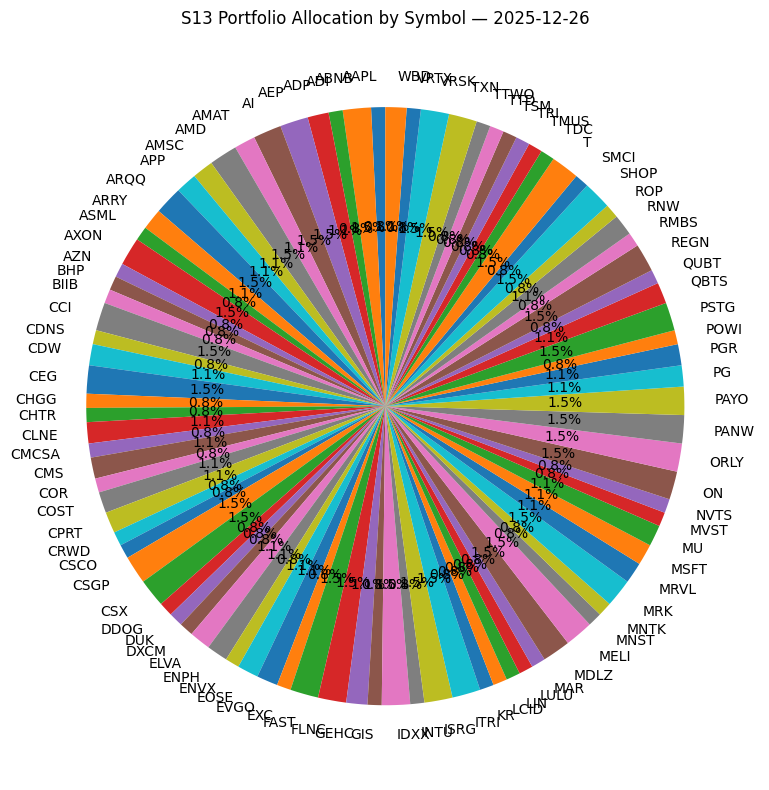

In [69]:
# --- Pie chart: S13 Portfolio Allocation by Symbol ---

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

STRAT_COL = "pct_S13"
TITLE = "S13 Portfolio Allocation by Symbol"

# 1. Load a table that has date, symbol and STRAT_COL
df = None

# Prefer in-memory ALL allocation if this notebook has already built it
if "alloc_all" in globals() and STRAT_COL in alloc_all.columns:
    df = alloc_all.copy()
else:
    p = Path("./out/alloc_percent_all_with_today.csv")
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"])
    else:
        raise RuntimeError("No ALL allocation file with today plan found.")

if df is None or df.empty:
    raise RuntimeError(f"No allocation data containing {STRAT_COL} found.")

# 2. Clean types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["symbol"] = df["symbol"].astype(str)
if STRAT_COL not in df.columns:
    raise RuntimeError(f"DataFrame does not contain a {STRAT_COL} column.")

# 3. Restrict to latest date and TODAY plan rows
latest_date = df["date"].max()

if "note" in df.columns:
    today_slice = df[df["date"].eq(latest_date) & df["note"].eq("today_plan")].copy()
    # Fallback: if somehow no today_plan rows, use all rows for that date
    if today_slice.empty:
        today_slice = df[df["date"].eq(latest_date)].copy()
else:
    today_slice = df[df["date"].eq(latest_date)].copy()

# 4. Aggregate to one row per symbol and keep only positive weights
today_slice = (
    today_slice
    .groupby("symbol", as_index=False)[STRAT_COL]
    .sum()
)

# Prefer symbols with positive weight, but fall back to full set if all zeros
pos = today_slice[today_slice[STRAT_COL] > 0].copy()
if not pos.empty:
    today_slice = pos

labels = today_slice["symbol"].tolist()
sizes = today_slice[STRAT_COL].astype(float).tolist()

# Avoid all-zero pie (e.g., if strategy is inactive)
if sizes and all(v == 0 for v in sizes):
    sizes = [1.0 / len(sizes)] * len(sizes)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title(f"{TITLE} — {latest_date.date().isoformat()}")
plt.tight_layout()

# 5. Save PNG (if configured)
fig_dir = Path("./out/figs")
fig_dir.mkdir(parents=True, exist_ok=True)
png_path = fig_dir / "s13_allocation_pie.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")
print(f"Saved pie chart to {png_path}")

plt.show()


Saved pie chart to out\figs\s11_allocation_select_pie.png


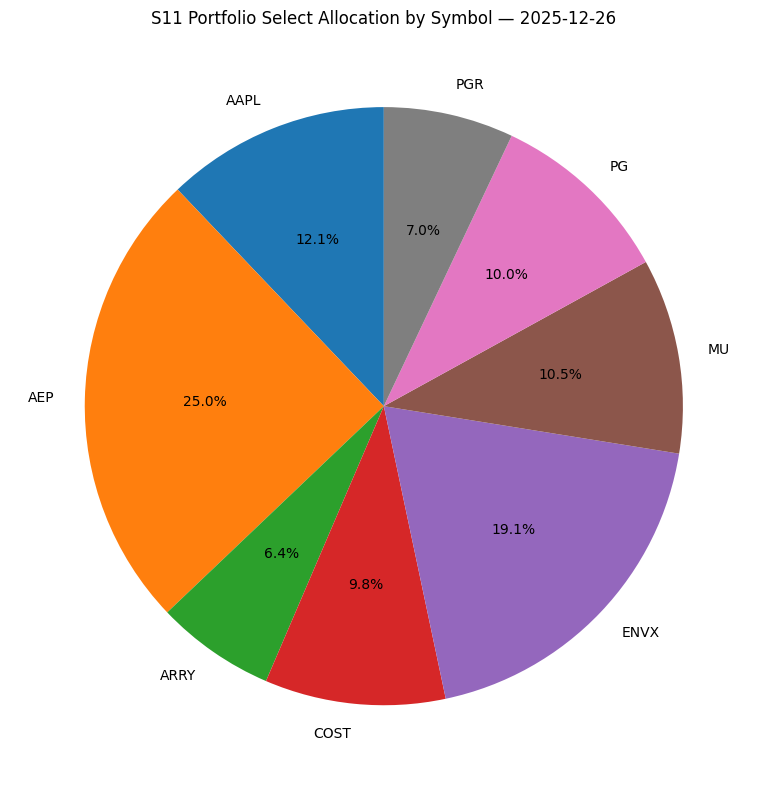

In [70]:
# --- Pie chart: S11 Portfolio Select Allocation by Symbol ---

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

STRAT_COL = "pct_S11"
TITLE = "S11 Portfolio Select Allocation by Symbol"

# 1. Load a table that has date, symbol and STRAT_COL
df = None

# Prefer in-memory SELECT allocation if this notebook has already built it
if "alloc_sel" in globals() and STRAT_COL in alloc_sel.columns:
    df = alloc_sel.copy()
else:
    p = Path("./out/alloc_percent_select_with_today.csv")
    if p.exists():
        df = pd.read_csv(p, parse_dates=["date"])
    else:
        raise RuntimeError("No SELECT allocation file with today plan found.")

if df is None or df.empty:
    raise RuntimeError(f"No allocation data containing {STRAT_COL} found.")

# 2. Clean types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["symbol"] = df["symbol"].astype(str)
if STRAT_COL not in df.columns:
    raise RuntimeError(f"DataFrame does not contain a {STRAT_COL} column.")

# 3. Restrict to latest date and TODAY plan rows
latest_date = df["date"].max()

if "note" in df.columns:
    today_slice = df[df["date"].eq(latest_date) & df["note"].eq("today_plan")].copy()
    # Fallback: if somehow no today_plan rows, use all rows for that date
    if today_slice.empty:
        today_slice = df[df["date"].eq(latest_date)].copy()
else:
    today_slice = df[df["date"].eq(latest_date)].copy()

# 4. Aggregate to one row per symbol and keep only positive weights
today_slice = (
    today_slice
    .groupby("symbol", as_index=False)[STRAT_COL]
    .sum()
)

# Prefer symbols with positive weight, but fall back to full set if all zeros
pos = today_slice[today_slice[STRAT_COL] > 0].copy()
if not pos.empty:
    today_slice = pos

labels = today_slice["symbol"].tolist()
sizes = today_slice[STRAT_COL].astype(float).tolist()

# Avoid all-zero pie (e.g., if strategy is inactive)
if sizes and all(v == 0 for v in sizes):
    sizes = [1.0 / len(sizes)] * len(sizes)

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title(f"{TITLE} — {latest_date.date().isoformat()}")
plt.tight_layout()

# 5. Save PNG (if configured)
fig_dir = Path("./out/figs")
fig_dir.mkdir(parents=True, exist_ok=True)
png_path = fig_dir / "s11_allocation_select_pie.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")
print(f"Saved pie chart to {png_path}")

plt.show()
